In [5]:
# Import necessary libraries
import pandas as pd
from collections import defaultdict
import geopandas as gpd
from shapely import wkt
import shapely

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import pickle
%matplotlib inline
import datetime
import time
import numpy as np
import xml.etree.ElementTree as ET 
import matsim

import utm
from shapely.geometry import Polygon, Point
import gzip
from matplotlib import cm

import matplotlib.ticker as ticker
import matplotlib.font_manager as font_manager
import matplotlib as mpl
from matplotlib.lines import Line2D
from tqdm import tqdm
from matplotlib.colors import LinearSegmentedColormap
import json



In [6]:
with open('input/regionclusters.pkl', 'rb') as pickle_file: # liegt in ikg-useful-share/USEfUL XT/Modul 3/Auswertung-Oskar/input/
    regionclusters = pd.read_pickle(pickle_file)

def determine_area_type(raumtyp):
    if raumtyp in [1, 2, 3]:
        return 'Urban'
    elif raumtyp in [4, 5, 6]:
        return 'Suburban'
    elif raumtyp in [7, 8]:
        return 'Rural'
    else:
        return 'unknown'
    
category_dict = {
    "1": "Metropolitan Center",
    "2": "High-Density Residential Use",
    "3": "Dense Mixed Use",
    "4": "Residential Use",
    "5": "Industrial Use",
    "6": "Urbanized Periphery",
    "7": "Rural with Industrial Influence",
    "8": "Rural without Industrial Influence"
}


# Wende die Funktion auf die Spalte raumtyp an und erstelle die neue Spalte area_type
regionclusters['area_type_agg'] = regionclusters['raumtyp'].apply(determine_area_type)
regionclusters['area_type'] = regionclusters['raumtyp'].astype(str).map(category_dict)

# Explode the multipolygons into individual polygons
regionclusters_split = regionclusters.explode(index_parts=False)

# Reset index to clean up the DataFrame
regionclusters_split.reset_index(drop=True, inplace=True)

# Display the resulting DataFrame
regionclusters_split

C:\Users\bienzeisler\AppData\Local\Programs\Python\Python313\Lib\pickle.py:1760: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  setstate(state)


,name,raumtyp,area_type_agg,area_type,geometry
0,Metropoles Zentrum,1,Urban,Metropolitan Center,"POLYGON ((550245.757 5803780.217, 550498.506 5..."
1,Zentrumsnah hochverdichtete Wohnnutzung,2,Urban,High-Density Residential Use,"POLYGON ((551841.918 5799807.714, 551822.177 5..."
2,Zentrumsnah hochverdichtete Wohnnutzung,2,Urban,High-Density Residential Use,"POLYGON ((548246.648 5803396.842, 548436.729 5..."
3,Zentrumsnah hochverdichtete Wohnnutzung,2,Urban,High-Density Residential Use,"POLYGON ((551382.558 5803547.894, 551322.051 5..."
4,Zentrumsnah verdichtete Mischnutzung,3,Urban,Dense Mixed Use,"POLYGON ((550296.319 5800661.942, 550326.482 5..."
...,...,...,...,...,...
92,Umland dörflich ohne gewerblichen Einfluss,8,Rural,Rural without Industrial Influence,"POLYGON ((555171.141 5811301.777, 555348.531 5..."
93,Umland dörflich ohne gewerblichen Einfluss,8,Rural,Rural without Industrial Influence,"POLYGON ((553603.43 5818427.593, 553504.77 581..."
94,Umland dörflich ohne gewerblichen Einfluss,8,Rural,Rural without Industrial Influence,"POLYGON ((569144.127 5792666.928, 569149.889 5..."
95,Umland dörflich ohne gewerblichen Einfluss,8,Rural,Rural without Industrial Influence,"POLYGON ((567727.813 5795421.313, 567684.597 5..."


In [7]:
# Read the CSV file
folder = "input/"
areas = pd.read_csv( folder + "plz_areas.csv")  

# Convert the 'WKT' column to Shapely MultiPolygon geometry
areas['geometry'] = areas['WKT'].apply(lambda wkt_str: wkt.loads(wkt_str))

# Create a GeoDataFrame
gdf_areas = gpd.GeoDataFrame(areas, geometry='geometry')

# Set the coordinate reference system (CRS)
gdf_areas.crs = 'EPSG:25832'  # Set the appropriate CRS if it's different


# Import Network
# MATSim network als Geopandas dataframe inkl. LINESTRINGS einlesen
# network = matsim.read_network('D:\\Hannover Daten\\MatSim\\Network XT\\car_network_encfix.xml.gz').as_geo().set_crs('epsg:25832') # liegt in ikg-useful-share/USEfUL XT/Modul 3/Auswertung-Oskar/input/
network = matsim.read_network('input/car_network_encfix.xml.gz').as_geo().set_crs('epsg:25832')
# dict mit Netzwerk Link Längen
# link_length = network[['link_id', 'length']].set_index('link_id').to_dict()['length']
network.head()

# falls vorhanden Ergebnisse der nächsten Zellen laden, sonst überspringen
with open('input/regionclusters.pkl', 'rb') as pickle_file: # liegt in ikg-useful-share/USEfUL XT/Modul 3/Auswertung-Oskar/input/
    regionclusters = pd.read_pickle(pickle_file)
with open('input/networkplus.pkl', 'rb') as pickle_file: # liegt in ikg-useful-share/USEfUL XT/Modul 3/Auswertung-Oskar/input/
    networkplus = pd.read_pickle(pickle_file)     




C:\Users\bienzeisler\AppData\Local\Programs\Python\Python313\Lib\pickle.py:1760: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  setstate(state)


In [8]:
link_length = network[['link_id', 'length']].set_index('link_id').to_dict()['length']
link_geometry = network[['link_id', 'geometry']].set_index('link_id').to_dict()['geometry']
# dict mit Netzwerk Link Raumtypen
link_raumtyp = networkplus['raumtyp'].to_dict()

In [9]:
# Create a dictionary linking each area type code to its description
area_type_dict = {
    1: "Metropolitan Center",
    2: "High-Density Residential Use",
    3: "Dense Mixed Use",
    4: "Residential Use",
    5: "Industrial Use",
    6: "Urbanized Periphery",
    7: "Rural with Industrial Influence",
    8: "Rural without Industrial Influence"
}

from matplotlib.colors import to_hex
# Define the desired order of legend labels in English
# Create a dictionary linking each category to a color



category_color_dict = {
    "Metropolitan Center": "#482878",
    "High-Density Residential Use": "#3f4989",
    "Dense Mixed Use": "#31688e",
    "Residential Use": "#26828e",
    "Industrial Use": "#1f9e89",
    "Urbanized Periphery": "#35b779",
    "Rural with Industrial Influence": "#6fce58",
    "Rural without Industrial Influence": "#b5de2b"
}



category_color_dict_num = {
    0: "#482878",
    1: "#3f4989",
    2: "#31688e",
    3: "#26828e",
    4: "#1f9e89",
    5: "#35b779",
    6: "#6fce58",
    7: "#b5de2b"
}



# Create a dictionary linking each category to a color
category_color = {category: i / (len(category_color_dict) - 1) for i, category in enumerate(category_color_dict)}

# Create the colormap
cmap = LinearSegmentedColormap.from_list("custom_cmap", sns.color_palette("viridis_r", len(category_color_dict))[::-1])

# Convert the colormap to a dictionary
palette_dict = {cat: to_hex(cmap(category_color[cat])) for cat in category_color_dict}


In [ ]:
# def Methoden

# vehicle string pattern
def parse_events(event_file):
    """
    This function parses events from a given event file. It filters out events of type 'left link' and 'actstart'.
    It also counts the number of events for different types of vehicles and stores the last link for each vehicle.
    
    Args:
        event_file (str): The path to the event file to be parsed.
        
    Returns:
        vehicle_tour (dict): A dictionary mapping each vehicle to a list of links in its tour.
        service_events (dict): A dictionary mapping each person to a list of service events.
        network_volumes (DataFrame): A DataFrame containing the counts of each type of vehicle on each link.
    """
    
    # Only returns events of type 'left link' and 'actstart:
    events = matsim.event_reader(event_file, types='left link,actstart')

    # defaultdict creates a blank dict entry on first reference; similar to {} but more friendly
    link_counts_trucks = defaultdict(int)
    link_counts_vans = defaultdict(int)
    link_counts_bikes = defaultdict(int)
    link_counts_cars = defaultdict(int)

    vehicle_tour = defaultdict(list)
    service_events = defaultdict(list)
    last_link = defaultdict(str)

    for event in events:
        # skip next day events
        if event['time'] > DAYEND: continue

        # on link left
        if event['type'] == 'left link':
            vehicle = event['vehicle']
            # fix broken ID encodings in basecase
            # vehicle = vehicle.encode('Windows 1252').decode('UTF-8') # für die Auswertung egal
            # identify CEP truck
            if '_Supply_Vehicle_' in vehicle or '_veh_supply_' in vehicle:
                if event['link'] != last_link[vehicle]:
                    link_counts_trucks[event['link']] += 1
                    vehicle_tour[vehicle].append(event['link'])
                    last_link[vehicle] = event['link']
            # identify vans (CEP & eGrocery)
            elif '_CEP_Vehicle_' in vehicle or '_veh_cep_' in vehicle or '_egrocery_van_' in vehicle:
                if event['link'] != last_link[vehicle]:
                    link_counts_vans[event['link']] += 1
                    vehicle_tour[vehicle].append(event['link'])
                    last_link[vehicle] = event['link']
            # identify bikes
            elif '_cargoBike_' in vehicle or '_cargobike_' in vehicle:
                if event['link'] != last_link[vehicle]:
                    link_counts_bikes[event['link']] += 1
                    vehicle_tour[vehicle].append(event['link'])
                    last_link[vehicle] = event['link']
        elif event['type'] == 'actstart':
            person = event['person']
            # fix broken ID encodings in basecase
            # person = person.encode('Windows 1252').decode('UTF-8') # für die Auswertung egal
            # catch last tour link
            if event['actType'] == 'end':
            # identify CEP truck persons
                if '_Supply_Vehicle_' in person or '_veh_supply_' in person:
                    link_counts_trucks[event['link']] += 1
                    vehicle_tour[person].append(event['link'])
                # identify van persons
                elif '_CEP_Vehicle_' in person or '_veh_cep_' in person or '_egrocery_van_' in person:
                    link_counts_vans[event['link']] += 1
                    vehicle_tour[person].append(event['link'])
                # identify bike persons
                elif '_cargoBike_' in person or '_cargobike_' in vehicle:
                    link_counts_bikes[event['link']] += 1
                    vehicle_tour[person].append(event['link'])
            # catch services
            elif event['actType'] == 'service':
                service_events[person].append(event['link'])
    


    # convert link_counts dict to a pandas dataframe
    link_counts_trucks = pd.DataFrame.from_dict(link_counts_trucks, orient='index', columns=['truck_count']).rename_axis('link_id')
    link_counts_vans = pd.DataFrame.from_dict(link_counts_vans, orient='index', columns=['van_count']).rename_axis('link_id')
    link_counts_bikes = pd.DataFrame.from_dict(link_counts_bikes, orient='index', columns=['bike_count']).rename_axis('link_id')
    link_counts_cars = pd.DataFrame.from_dict(link_counts_cars, orient='index', columns=['car_count']).rename_axis('link_id')

    # attach counts to our Geopandas network from above
    network_volumes = network.merge(link_counts_trucks, on='link_id', how='left').merge(link_counts_vans, on='link_id', how='left').merge(link_counts_bikes, on='link_id', how='left').merge(link_counts_cars, on='link_id', how='left')
    network_volumes['car_count'] = network_volumes['car_count'].fillna(0)
    network_volumes['truck_count'] = network_volumes['truck_count'].fillna(0)
    network_volumes['van_count'] = network_volumes['van_count'].fillna(0)
    network_volumes['bike_count'] = network_volumes['bike_count'].fillna(0)
    network_volumes['total_count'] = network_volumes['truck_count'] + network_volumes['van_count'] + network_volumes['bike_count']

    return vehicle_tour, service_events, network_volumes


def vehicle_stats(vehicle_tour, service_events):
    """
    This function calculates statistics for each vehicle, including the number of services, total tour length,
    distance to the first service, and distribution of services over different types of areas.
    
    Args:
        vehicle_tour (dict): A dictionary mapping each vehicle to a list of links in its tour.
        service_events (dict): A dictionary mapping each person to a list of service events.
        
    Returns:
        veh_df (DataFrame): A DataFrame containing statistics for each vehicle.
    """
        
    # init Ergebnis Objekte
    vehicle_stats = list()

    # Loop über Fahrzeuge und ihre Services
    for veh, ser in service_events.items():
        # Unterscheidung Fahrzeugtypen
        if '_Supply_Vehicle_' in veh or '_veh_supply_' in veh:
            c = 'truck'            
        if '_CEP_Vehicle_' in veh or '_veh_cep_' in veh or '_egrocery_van_' in veh:
            c = 'van'
        if '_cargoBike_' in veh or '_cargobike_' in veh:
            c = 'bike'
        
        # tourlen = 0
        # firstservicedist = None
        # # Loop über alle Tourlinks des Fahrzeuges
        # for link in vehicle_tour[veh]:
        #     # falls erster Service erreicht, Strecke bis dahin speichern
        #     if link == ser[0] and firstservicedist is None:
        #         firstservicedist = tourlen
        #     # Streckenlänge aufsummieren
        #     tourlen += link_length[link]
        # # Sonderfälle abfangen, wo ein Service kurz vor Tagesende beginnt und am nächsten Tag weitergefahren wird
        # if firstservicedist is None: firstservicedist = tourlen

        tourlen = 0
        firstservicedist = None
        service_dists = dict()

        visited_links = vehicle_tour[veh]
        if not ser:
            continue

        for link in visited_links:
            # Strecke aufsummieren
            link_km = link_length[link] / 1000  # Direkt km
            tourlen += link_km
            for s in ser:
                # Sobald Servicepunkt erreicht (einmalig erfassen)
                if link == s and s not in service_dists:
                    service_dists[s] = tourlen
                    if firstservicedist is None:
                        firstservicedist = tourlen  # Speichere ersten Treffer

        # Fallback: falls ein Service nicht in der Tour auftaucht
        for s in ser:
            if s not in service_dists:
                service_dists[s] = tourlen
        if firstservicedist is None:
            firstservicedist = tourlen
           
        indexService = 0
        start_service_distance_count = False
        currentServiceDist = 0
        serviceDistList= []    

        # Service Verteilung über Raumtypen ermitteln
        raumtypen_services = defaultdict(int)
        for s in ser:
            rt = link_raumtyp.get(s, 0) # keinem Raumtyp zugeordnet -> 0
            raumtypen_services[rt] += 1        
    

        summ_service_distances = 0
        previous_time = 0     


        vehicle_stats.append([
            veh, c, len(ser),
            tourlen ,
            firstservicedist ,
            raumtypen_services,
            service_dists,
            firstservicedist   # explizite Spalte für initial_delivery_distance
        ])


    # Dataframe aus Liste
    veh_df = pd.DataFrame(vehicle_stats, columns=[
        'vehicle_id', 'veh_class', 'service_num',
        'tour_km', 'first_service_dist',
        'raumsplit', 'service_dists',
        'initial_delivery_distance'
    ])

    return veh_df

# Definition of help-methods needed for the convertion process

# Method returning the index of an element of a dictionary
def get_nth_key(dictionary, n=0):
    """
    This function returns the nth key of a dictionary.
    
    Args:
        dictionary (dict): The dictionary to get the key from.
        n (int): The index of the key to get. Default is 0.
        
    Returns:
        key: The nth key of the dictionary.
    """
        
    if n < 0:
        n += len(dictionary)
    for i, key in enumerate(dictionary.keys()):
        if i == n:
            return key
    raise IndexError("dictionary index out of range") 

    
# Get Logistic Provider from XML ID
def getProviderFromID(carrierID):
    """
    This function returns the provider name based on the carrier ID.
    
    Args:
        carrierID (str): The ID of the carrier.
        
    Returns:
        str: The name of the provider.
    """
        
    if("dhl" in str(carrierID)):
        return "dhl"  
    elif("amazon" in str(carrierID)):
        return "amazon"  
    elif("ups" in str(carrierID)):
        return "ups"  
    elif("gls" in str(carrierID)):
        return "gls"  
    elif("dpd" in str(carrierID)):
        return "dpd"  
    elif("fedex" in str(carrierID)):
        return "fedex"  
    elif("hermes" in str(carrierID)):
        return "hermes"  
    elif("wl" in str(carrierID)):
        return "White-Label"  
    else:
        raise ValueError('Carrier Provider unknown: ' + str(carrierID))
        
# Definition of needen Classes: Carrier, Vehicle, Plan & Service with Variables

# A carrier object has an ID and dictionaries with all Vehicles and all Services
class Carrier:  
    """
    This class represents a Carrier with an ID and dictionaries with all Vehicles and all Services.
    """
        
    def __init__(self, carrierID): 
        self.carrierID = carrierID 
        self.vehicles = {} 
        self.services = {}   
        self.missedDeliveries = []
        self.logisticProvider = getProviderFromID(self.carrierID)
        
    def __str__(self):
        return "[Carrier ID: " + str(self.carrierID) + " with " + str(len(self.vehicles)) + " Vehicles and " + str(len(self.services)) + " Services]"
    
    def __repr__(self):
        return self.__str__()
    
    def getNumberOfVehicles(self):
        return (len(self.vehicles))
    
    def getNumberOfServices(self):
        return (len(self.services))
        
    def addVehicle(self, vehicle): 
        self.vehicles[vehicle.getVehicleId] = vehicle
        
    def addService(self, service): 
        self.services[service.getServiceID] = service

    def getTotalNumberofServices(self):  
        return sum((s.getDemand() for s in self.services.values()))
    
    def getProvider(self):
        return self.logisticProvider
    
    def getServices(self): 
        return [s for s in self.services.values()]   
    
    def getCarrierId(self): 
        return self.carrierID    
    
    def getVehicles(self): 
        return self.vehicles
    
    def getMissedDeliveries(self): 
        return self.missedDeliveries  
    
    def setMissedDeliveries(self, missDeliveries): 
        self.missedDeliveries = missDeliveries


# A Vehicle has an ID, a Typ and you can add Plans to this vehicles with services and Routes. 
# These Vehicles / Plans have to be converted to Sumo! 
class Vehicle: 
    """
    This class represents a Vehicle with an ID, a Type and you can add Plans to this vehicles with services and Routes.
    """
        
    def __init__(self, vehicleID, vehicleType): 
        self.vehicleID = vehicleID 
        self.vehicleType = vehicleType 
        self.plans = []
        
    def __str__(self):
        return "[Vehicle ID: " + str(self.vehicleID) + " with Type: " + self.vehicleType +"]"
    
    def __repr__(self):
        return self.__str__()
    
    def addVehiclePlan(self, plan): 
        self.plans.append(plan)
        
    def changeVehicleType(self, vehicleType): 
        self.vehicleType == vehicleType
        
    def getVehicleId(self): 
        return self.vehicleID
    
    def getPlans(self):
        return self.plans


# A Plan is a sequence of Activies (start, service, service, ... , end)
# all important Information are stored in the activities / legs dictionary
# The Order of the sequence is stored as a list called "planSequence"
class Plan:  
    """
    This class represents a Plan which is a sequence of Activities (start, service, service, ... , end).
    """
        
    def __init__(self, planId, vehicle, activities, legs): 
        self.planId = planId
        self.vehicle = vehicle
        self.activities = activities 
        self.legs = legs 
        self.planSequence = [] 
        
    def __str__(self):
        return "[Plan ID: " + str(self.planId) + " with " + str(len(self.activities)) +" Activities and " + str(len(self.legs)) + " Legs]"
    
    def __repr__(self):
        return self.__str__()
    
    def getPlanSequence(self):
        return self.planSequence
    
    def createInternalPlanSequence(self):
        for i in range (len(self.legs)):            
            self.planSequence.append(get_nth_key(self.activities, i))
            self.planSequence.append(get_nth_key(self.legs, i))
        self.planSequence.append(get_nth_key(self.activities, len(self.activities)-1))    

# A Service is a data Container storing all availble Infomation from the CSV-File
class Service(): 
    """
    This class represents a Service which is a data Container storing all available Information from the CSV-File.
    """
        
    def __init__(self, serviceType , serviceID, capacityDemand, duration, link, extra_attributes=None):
        self.serviceType = serviceType
        self.serviceID = serviceID 
        self.capacityDemand = capacityDemand 
        self.duration = duration 
        self.link = link 
        self.extra_attributes = extra_attributes or {}
        
    def __str__(self):
        return "[Service ID: " + str(self.serviceID) + "(Type: " + str(self.serviceType) + ") with a CapacityDemand of " + str(self.capacityDemand) +" to Link: " + str(self.link) + "]"
    
    def __repr__(self):
        return self.__str__()

    def getAttribute(self, key, default=None):
        return self.extra_attributes.get(key, default)
    
    def getServiceType(self): 
        return self.serviceType
        
    def changeVehicleType(self, vehicleType): 
        self.vehicleType == vehicleType
        
    def getDemand(self): 
        return self.capacityDemand
        
    def getServiceID(self): 
        return self.serviceID
    
    def getServiceLink(self): 
        return self.serviceID
    
def extract_provider(vehicle_id):
    """
    This function extracts the provider from the vehicle ID.
    
    Args:
        vehicle_id (str): The ID of the vehicle.
        
    Returns:
        str: The name of the provider.
    """
        
    return vehicle_id.split("_")[1]

def extract_veh_size(vehicle_id):
    """
    Extracts the vehicle size from the vehicle ID by looking for 'size_' and returning the next token.
    
    Args:
        vehicle_id (str): The ID of the vehicle.
        
    Returns:
        str: The vehicle size (e.g., 'l', 'm', 'l'), or 'unknown' if not found.
    """
    try:
        parts = vehicle_id.split("size_")
        if len(parts) > 1:
            return parts[1].split("_")[0]
        else:
            return "unknown"
    except Exception as e:
        print(f"Error extracting vehicle size from '{vehicle_id}': {e}")
        return "unknown"

def extract_main_area_type(raumsplit):
    """
    This function extracts the main area type from the raumsplit.
    
    Args:
        raumsplit (dict): The dictionary containing the raumsplit.
        
    Returns:
        str: The main area type.
    """
        
    return max(raumsplit.items(), key=lambda x: x[1])[0]

def process_vehicle_data(veh_df_van):
    """
    This function processes the vehicle data and adds provider, vehicle size, and main area type to the DataFrame.
    
    Args:
        veh_df_van (DataFrame): The DataFrame containing the vehicle data.
        
    Returns:
        DataFrame: The processed DataFrame.
    """
        
    veh_df_van['provider'] = veh_df_van['vehicle_id'].apply(extract_provider)
    veh_df_van['veh_size'] = veh_df_van['vehicle_id'].apply(extract_veh_size)
    veh_df_van['main_area_type'] = veh_df_van['raumsplit'].apply(extract_main_area_type)

    return veh_df_van

def get_vehicles(vehicle_tour):
    """
    This function gets the vehicles from the vehicle tour.
    
    Args:
        vehicle_tour (dict): The dictionary containing the vehicle tour.
        
    Returns:
        list: The list of vehicles.
    """
        
    return [vehicle for vehicle in vehicle_tour if "_supply_" not in vehicle]

def create_plot_data(vehicles, event_file):
    """
    This function creates the plot data.
    
    Args:
        vehicles (list): The list of vehicles.
        event_file (str): The path to the event file.
        
    Returns:
        DataFrame: The DataFrame containing the plot data.
    """
        
    plot_data = pd.DataFrame({
    "Start time" : [0],
    "End time" : [0],
    "Tour Duration" : [0],
    "Service Duration" : [0],
    "Travel Duration" : [0],
    }, index=[vehicles,])

    #calculate start and end time
    events = matsim.event_reader(event_file, types='actstart,actend')
    event_lists = { 'start': [], 'end': [] }

    for event in events:
        if "_supply_" in event["person"]:
            continue
        if event['actType'] == "start" and event['type'] == "actend":
            event_lists['start'].append(event)
        if event['actType'] == "end" and event['type'] == "actstart":
            event_lists['end'].append(event)
    df_start = pd.DataFrame(event_lists['start'])
    df_end = pd.DataFrame(event_lists['end'])

    for event in range(len(df_start)):
            plot_data["Start time"][df_start.iloc[event]["person"]] = df_start.iloc[event]['time']
    for event in range(len(df_end)):
            plot_data["End time"][df_end.iloc[event]["person"]] = df_end.iloc[event]['time']


    #calculate travel time - need to remove the service time
    events = matsim.event_reader(event_file, types='actstart,actend')
    event_lists = { 'start': [], 'end': [] }

    for event in events:
        if "_supply_" in event["person"]:
            continue
        if event['actType'] == "service" and event['type'] == "actend":
            event_lists['start'].append(event)
        if event['actType'] == "service" and event['type'] == "actstart":
            event_lists['end'].append(event)
    df_start = pd.DataFrame(event_lists['start'])
    df_end = pd.DataFrame(event_lists['end'])

    for row in range(len(plot_data)):
        plot_data.iloc[row]["Tour Duration"] = plot_data.iloc[row]["End time"] - (plot_data.iloc[row]["Start time"])

    startG = df_start.groupby("person")
    endG = df_end.groupby("person")

    for n,g in startG:
        time = 0

        g = g.reset_index(drop=True)   

        g2 = endG.get_group(n)
        g2 = g2.reset_index(drop=True)

        result = pd.merge(g, g2, left_index=True, right_index=True)

        for i in range(len(result)):
            time = time + (result.loc[i]["time_y"] - result.loc[i]["time_x"])

            plot_data.loc[n, "Service Duration"] = abs(time)

    for row in range(len(plot_data)):
        plot_data.iloc[row]["Travel Duration"] = plot_data.iloc[row]["Tour Duration"] - (plot_data.iloc[row]["Service Duration"])

    plot_data = plot_data.astype(str)
    # for row in range(len(plot_data)):
    #     plot_data.iloc[row]["Start time"] = time.strftime("%H:%M:%S", time.gmtime(int(plot_data.iloc[row]["Start time"])))
    #     plot_data.iloc[row]["End time"] = time.strftime("%H:%M:%S", time.gmtime(int(plot_data.iloc[row]["End time"])))
    #     plot_data.iloc[row]["Tour Duration"] = time.strftime("%H:%M:%S", time.gmtime(int(plot_data.iloc[row]["Tour Duration"])))
    #     plot_data.iloc[row]["Service Duration"] = time.strftime("%H:%M:%S", time.gmtime(int(plot_data.iloc[row]["Service Duration"])))
    #     plot_data.iloc[row]["Travel Duration"] = time.strftime("%H:%M:%S", time.gmtime(int(plot_data.iloc[row]["Travel Duration"])))



    plot_data.reset_index(inplace=True)
    plot_data = plot_data.rename(columns={'level_0': 'vehicle_id'})

    plot_data["Start time formatted"] = pd.to_datetime(plot_data['Start time'], unit='s')
    plot_data["End time formatted"] = pd.to_datetime(plot_data['End time'], unit='s')
    plot_data["Tour Duration formatted"] = pd.to_datetime(plot_data['Tour Duration'], unit='s')
    plot_data["Service Duration formatted"] = pd.to_datetime(plot_data['Service Duration'], unit='s')
    plot_data["Travel Duration formatted"] = pd.to_datetime(plot_data['Travel Duration'], unit='s')

    plot_data["Start time"] = pd.to_numeric(plot_data["Start time"])
    plot_data["End time"] = pd.to_numeric(plot_data["End time"])
    plot_data["Tour Duration"] = pd.to_numeric(plot_data["Tour Duration"])
    plot_data["Service Duration"] = pd.to_numeric(plot_data["Service Duration"])
    plot_data["Travel Duration"] = pd.to_numeric(plot_data["Travel Duration"])
    
    return plot_data

def parse_carriers_from_xml(root):
    """
    This function parses carriers from an XML root.
    
    Args:
        root (ElementTree): The XML root to parse carriers from.
        
    Returns:
        list: The list of carriers.
    """

    carriers = []
    totalVeh = 0
    ns = {"m": "http://www.matsim.org/files/dtd"}

    for carrierXML in root.findall("m:carrier", ns):
        carrierID = carrierXML.attrib.get("id")
        if "supply" in carrierID:
            continue

        newCarrier = Carrier(carrierID)

        for attributeXML in carrierXML.findall("m:attributes", ns):
            for attribute in attributeXML.findall("m:attribute", ns):
                if attribute.attrib.get("name") == "missedParcelDeliveriesAsString":
                    missedParcels = attribute.text
                    missedParcels = missedParcels.replace("[", "").replace("]", "").replace(" ", "")
                    missedServicePerCarrier = missedParcels.split(",")
                    newCarrier.setMissedDeliveries(missedServicePerCarrier)

        for serviceXML in carrierXML.findall(".//m:service", ns):
            serviceID = serviceXML.attrib.get("id")

            serviceCapacityDemand = int(serviceXML.attrib.get("capacityDemand"))
            serviceDuration = serviceXML.attrib.get("serviceDuration")
            serviceLink = serviceXML.attrib.get("to")

            known_keys = {"id", "capacityDemand", "serviceDuration", "to"}
            extra_attrs = {k: v for k, v in serviceXML.attrib.items() if k not in known_keys}

            attributes_element = serviceXML.find("m:attributes", ns)
            if attributes_element is not None:
                for attr in attributes_element.findall("m:attribute", ns):
                    key = attr.attrib.get("name")
                    value = attr.text
                    if key in ["b2b", "b2c"]:
                        try:
                            value = int(value)
                        except ValueError:
                            value = 0
                    extra_attrs[key] = value

            newService = Service(
                "service",
                serviceID,
                serviceCapacityDemand,
                serviceDuration,
                serviceLink,
                extra_attributes=extra_attrs
            )
            newCarrier.addService(newService)

        for plan in carrierXML.findall(".//m:plan", ns):
            if plan.attrib.get("selected") == "true":
                i = 0
                for tour in plan.findall(".//m:tour", ns):
                    i += 1
                    vehID = tour.attrib.get("vehicleId") + "_" + str(i)
                    vehicle = Vehicle(vehID, "cep")                    

                    b = 0
                    c = 0

                    activities = {}
                    legs = {}
                    routes = {}

                    for act in tour.findall(".//m:act", ns):
                        actType = act.attrib.get("type")
                        if actType == "start":
                            activities[actType] = act
                        elif actType == "end":
                            activities[actType] = act
                        else:
                            actID = act.attrib.get("serviceId")
                            activities[actID] = act

                    for leg in tour.findall(".//m:leg", ns):
                        legs["leg_" + str(b)] = leg
                        b += 1

                    for route in tour.findall(".//m:route", ns):
                        if route.text is None:
                            routes["route_" + str(c)] = None
                        else:
                            routes["route_" + str(c)] = route.text.split(" ")
                        c += 1

                    for key, value in legs.items():
                        routeKey = "route_" + str(key.split("_")[1])
                        route = routes.get(routeKey)
                        value.attrib["route"] = route

                    vehiclePlan = Plan("plan_" + vehID, vehicle, activities, legs)
                    vehiclePlan.createInternalPlanSequence()
                    vehicle.addVehiclePlan(vehiclePlan)
                    newCarrier.addVehicle(vehicle)

                totalVeh += newCarrier.getNumberOfVehicles()

        carriers.append(newCarrier)

    return carriers



def calculate_costs(row):
    veh_time_cost = 22.87 / 3600  # Kosten pro Sekunde

    if "size_l" in row['vehicle_id']:
        veh_cap, veh_fix, veh_km_cost = 230, 189.15, 0.386
    elif "size_m" in row['vehicle_id']: 
        veh_cap, veh_fix, veh_km_cost = 165, 171.78, 0.372
    else:
        if "supply_light_van" in row['vehicle_id']:
            veh_cap, veh_fix, veh_km_cost = 230, 189.15, 0.386
        elif "light" in row['vehicle_id']:
            veh_cap, veh_fix, veh_km_cost = 1000, 550.63, 0.48643
        else:
            veh_cap, veh_fix, veh_km_cost = 2000, 618.55, 0.555126     
      
     
    vehicle_fix_cost = veh_fix
    vehicle_km_cost = row["tour_km"] * veh_km_cost
    vehicle_time_cost = row["Tour Duration"] * veh_time_cost

    overtime_seconds = max(0, row["Tour Duration"] - (7.5 * 3600))
    overtime_cost = overtime_seconds * veh_time_cost

    vehicle_cost = vehicle_fix_cost + vehicle_km_cost + overtime_cost

    return pd.Series([vehicle_fix_cost, vehicle_km_cost, vehicle_time_cost, overtime_cost, vehicle_cost])



def add_vehicle_demand_to_result(carriers, result):
    
    """
    This function adds vehicle demand to the result DataFrame.
    
    Args:
        carriers (list):The list of carriers.
        result (DataFrame): The DataFrame to add vehicle demand to.
        
    Returns:
        DataFrame: The DataFrame with added vehicle demand.
    """

    required_cols = [
        'deliveries', 'missed deliveries', 'b2b_ration', 'b2c_ration',
        'ration_check', 'vehicle_load_factor', 'vehicle_deliver_factor',
        'vehicle_fix_cost', 'vehicle_km_cost', 'vehicle_time_cost',
        'overtime_cost', 'vehicle_cost', 'service_num'
    ]
    for col in required_cols:
        if col not in result.columns:
            result[col] = np.nan
    expected_ids = []
    
        
    veh = 0
    fail = 0

    # 1. Create a new dictionary to hold vehicle-service mappings
    vehicle_services_dict = {}

    for c in carriers:
        missedDeliveries = c.getMissedDeliveries()
        missed_deliveries_set = set(missedDeliveries) 

        services = c.getServices()

        print(f"🔍 Carrier {c.getCarrierId()} has {len(c.getVehicles())} vehicles")
        
        
        for k, v in c.getVehicles().items():
            veh = veh + 1 
            result_df_id = "freight_" + c.getCarrierId()+"_veh_"+v.getVehicleId()     
            expected_ids.append(result_df_id)   
         
            veh_df_res = result[result.vehicle_id == result_df_id]    
            if (len(veh_df_res) != 1):
                print(result_df_id)
                fail = fail + 1    
                
            mask = result.vehicle_id == result_df_id
            if mask.sum() == 0:
                print(f"⚠️ ID not found in result: {result_df_id}")   
            
            totalVehDemand = 0            
            missedParcels = 0

            b2b = 0
            b2c = 0

            # 2. Extract services for this vehicle
            veh_services = []
            services_dict = {s.getServiceID(): s for s in services}

            for a in v.getPlans()[0].activities:
                if "service" in a:
                    for s in services:
                        if a == s.getServiceID():
                            service = services_dict.get(a)
                            veh_services.append(service)

                            service_id = s.getServiceID()
                            service_b2b = int(s.getAttribute("b2b", 0))
                            service_b2c = int(s.getAttribute("b2c", 0))

                            # Nachfrage aufsummieren
                            b2b += service_b2b
                            b2c += service_b2c
                            serviceDemand = service_b2b + service_b2c
                            totalVehDemand += serviceDemand


                            merged = s.getAttribute("mergedMetadata", None)
                            
                            if service_id in missed_deliveries_set:
                                missedParcels += serviceDemand  
                            elif merged:
                                try:
                                    merged_dict = json.loads(merged)

                                    # Validierung: mixed muss zu merged passen
                                    if "MIXED" not in service_id.upper():
                                        print(f"⚠️ Warning: mergedMetadata found, but service ID does not indicate MIXED: {service_id}")

                                    for sid, md in merged_dict.items():
                                        if sid in missed_deliveries_set:
                                            # Sub-service demand: prefer capacity, else len(weights), else 1
                                            sub_cap_raw = md.get("capacity", 0)
                                            try:
                                                sub_cap = int(sub_cap_raw)
                                            except Exception:
                                                sub_cap = 0

                                            sub_weights_raw = md.get("weights", [])
                                            # Normalize weights to a list
                                            if isinstance(sub_weights_raw, str):
                                                try:
                                                    parsed = json.loads(sub_weights_raw)
                                                    sub_weights = parsed if isinstance(parsed, list) else [parsed]
                                                except Exception:
                                                    sub_weights = [sub_weights_raw]
                                            elif isinstance(sub_weights_raw, (list, tuple)):
                                                sub_weights = list(sub_weights_raw)
                                            else:
                                                # float/None/other
                                                sub_weights = []

                                            # Assert consistency if both present
                                            if sub_cap > 0 and len(sub_weights) > 0:
                                                assert sub_cap == len(sub_weights), (
                                                    f"Mismatch in merged service {sid}: "
                                                    f"capacity={sub_cap}, len(weights)={len(sub_weights)}"
                                                )

                                            # Final sub-demand
                                            sub_demand = sub_cap if sub_cap > 0 else (len(sub_weights) if len(sub_weights) > 0 else 1)

                                            # Count only missed sub-services
                                            if sid in missed_deliveries_set:
                                                missedParcels += sub_demand
                                except Exception as e:
                                    print(f"⚠️ Error while parsing mergedMetadata for {service_id}: {e}")


                                
                                    
            vehicle_services_dict[result_df_id] = veh_services                         
            veh_cap = 230 if "size_l" in result_df_id else 165

            b2b_ration = b2b / totalVehDemand
            b2c_ration = b2c / totalVehDemand
            
            result.loc[result.vehicle_id == result_df_id, 'b2b_ration'] = b2b_ration
            result.loc[result.vehicle_id == result_df_id, 'b2c_ration'] = b2c_ration
            result.loc[result.vehicle_id == result_df_id, 'ration_check'] = b2b_ration + b2c_ration

            result.loc[result.vehicle_id == result_df_id, 'deliveries'] = totalVehDemand
            if result[result.vehicle_id == result_df_id].empty:
                print(f"Assignment failed for: {result_df_id}")
            
            result.loc[result.vehicle_id == result_df_id, 'missed deliveries'] = round(missedParcels,0)
            
             # Anwenden der Funktion auf den DataFrame
            cols = ['vehicle_fix_cost', 'vehicle_km_cost', 'vehicle_time_cost', 'overtime_cost', 'vehicle_cost']
            result[cols] = result.apply(calculate_costs, axis=1)
             

            result.loc[result.vehicle_id == result_df_id, 'vehicle_load_factor'] = totalVehDemand / veh_cap
            result.loc[result.vehicle_id == result_df_id, 'vehicle_deliver_factor'] = (totalVehDemand - missedParcels) / totalVehDemand
    
    validate_vehicle_id_assignment(result, expected_ids)
    
    result['deliveries_per_stop'] = result['deliveries'] / result['service_num']
    result['Hannover'] = result['vehicle_id'].apply(lambda x: any(plz in x for plz in plzList))

    result['services'] = result['vehicle_id'].map(vehicle_services_dict)
    
    return result

def validate_vehicle_id_assignment(result, expected_ids):
    """
    Validates whether all expected vehicle IDs are present in the result DataFrame.
    Prints helpful diagnostics for debugging.
    
    Args:
        result (DataFrame): The result DataFrame after add_vehicle_demand_to_result.
        expected_ids (list): List of vehicle_id strings that should exist in result.
    """
    actual_ids = result['vehicle_id'].astype(str).tolist()

    missing_ids = [vid for vid in expected_ids if vid not in actual_ids]
    duplicate_ids = result['vehicle_id'][result['vehicle_id'].duplicated()].unique().tolist()
    empty_ids = result['vehicle_id'].isna().sum()

    print("\n📋 Vehicle ID Validation Report")
    print("──────────────────────────────")
    print(f"🔢 Expected IDs total: {len(expected_ids)}")
    print(f"✅ Found: {len(expected_ids) - len(missing_ids)}")
    print(f"❌ Missing: {len(missing_ids)}")
    print(f"🔁 Duplicates: {len(duplicate_ids)}")
    print(f"⚠️ Empty vehicle_id entries: {empty_ids}")
    
    if missing_ids:
        print("\n❌ Missing IDs (first 10 shown):")
        for mid in missing_ids[:10]:
            print(f"  - {mid}")
    
    if duplicate_ids:
        print("\n🔁 Duplicate vehicle_ids:")
        for did in duplicate_ids:
            print(f"  - {did}")



In [11]:
# This is a constant representing the number of seconds in a day.
DAYEND = 24*3600

# This is a list of postal codes (it seems) that the script will be working with.
plzList = ["30159", "30161", "30163", "30165", "30167", "30169", "30171", "30173", "30175", "30177", "30179", "30419", "30449"
           ,"30451" ,"30453" ,"30455" ,"30457" ,"30459" ,"30519" ,"30521" ,"30539" ,"30559" ,"30625" ,"30627" ,"30629",
           "30625" , "30627", "30629", "30655", "30657", "30659", "30669", "31303", "31303"]

# This is the path to the folder where input files are stored.
folderPath = "Input/SimRes/500-it/basecase_13052025/"
# folderPath = "Input/SimRes/BC_500_it_no_reduction/"

file = ""

# This is the name of the file where event data will be loaded.
eventFileName = "basecase_13052025.output_events.xml.gz"

# This is the name of the file where carrier data will be loaded.
carrierFileName = "basecase_13052025.output_carriers.xml.gz"


city = regionclusters[regionclusters.raumtyp < 7]

result_dataframes = {}
result_networks= {}

event_file = folderPath + file + eventFileName
carrier_file = folderPath + file + carrierFileName

print("Start Reading Event-file from: ", event_file)

vehicle_tour, service_events, network_volumes = parse_events(event_file)    
# Clip the network_volumes GeoDataFrame to the shape of gdf_areas
clipped_network_volumes = gpd.clip(network_volumes, gdf_areas)

veh_df = vehicle_stats(vehicle_tour, service_events)
veh_df_van = veh_df[veh_df.veh_class == "van"]

veh_df_truck = veh_df[~(veh_df.veh_class == "van")]

# Call the optimized function to process the vehicle data
veh_df_van = process_vehicle_data(veh_df_van)

vehicles = get_vehicles(vehicle_tour)
plot_data = create_plot_data(vehicles, event_file)

result = plot_data.merge(veh_df_van, left_on='vehicle_id', right_on='vehicle_id')

with gzip.open(carrier_file, mode="rt") as f:
    tree = ET.parse(f)
    root = tree.getroot()

carriers = parse_carriers_from_xml(root)
result = add_vehicle_demand_to_result(carriers, result)


Start Reading Event-file from:  Input/SimRes/500-it/basecase_13052025/basecase_13052025.output_events.xml.gz


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_27808\1287934133.py:90: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  network_volumes['car_count'] = network_volumes['car_count'].fillna(0)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_27808\1287934133.py:93: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  network_volumes['bike_count'] = network_volumes['bike_count'].fillna(0)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_27808\1287934133.py:464: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .

🔍 Carrier dhl_30926_1 has 8 vehicles
🔍 Carrier dhl_30926_0 has 8 vehicles
🔍 Carrier amazon_31535_0 has 7 vehicles
🔍 Carrier dpd_30890 has 6 vehicles
🔍 Carrier dpd_30419 has 4 vehicles
🔍 Carrier dpd_30539 has 2 vehicles
🔍 Carrier dpd_30659 has 2 vehicles
🔍 Carrier dpd_30657 has 3 vehicles
🔍 Carrier dpd_30655 has 2 vehicles
🔍 Carrier amazon_31535_1 has 7 vehicles
🔍 Carrier hermes_31535_0 has 5 vehicles
🔍 Carrier gls_31535 has 7 vehicles
🔍 Carrier gls_30449 has 2 vehicles
🔍 Carrier hermes_31535_1 has 6 vehicles
🔍 Carrier dpd_30880 has 5 vehicles
🔍 Carrier hermes_30855_0 has 6 vehicles
🔍 Carrier hermes_30855_1 has 4 vehicles
🔍 Carrier amazon_30419_0 has 4 vehicles
🔍 Carrier gls_30559 has 3 vehicles
🔍 Carrier amazon_30419_1 has 4 vehicles
🔍 Carrier dhl_30827_1 has 5 vehicles
🔍 Carrier dhl_30827_0 has 5 vehicles
🔍 Carrier dpd_30559 has 4 vehicles
🔍 Carrier gls_31515 has 7 vehicles
🔍 Carrier dhl_30880_0 has 7 vehicles
🔍 Carrier dhl_30880_1 has 7 vehicles
🔍 Carrier dhl_30880_2 has 6 vehicles
🔍

In [12]:
import json
import re
from shapely.geometry import Point
from collections import defaultdict

vehicle_coords = defaultdict(list)
vehicle_weights = defaultdict(list)

for carrier in carriers:
    services = carrier.getServices()
    vehicles = carrier.getVehicles()

    for v in vehicles.values():
        vehicle_id = f"freight_{carrier.getCarrierId()}_veh_{v.getVehicleId()}"
        for a in v.getPlans()[0].activities:
            if "service" not in a:
                continue

            for s in services:
                if a == s.getServiceID():
                    # --- Normale Koordinate ---
                    coord_raw = s.getAttribute("coord", None)
                    if coord_raw:
                        match = re.match(r"\(([\d\.]+);([\d\.]+)\)", coord_raw)
                        if match:
                            x, y = float(match.group(1)), float(match.group(2))
                            vehicle_coords[vehicle_id].append(Point(x, y))

                    # --- Normale Gewichte ---
                    weights_raw = s.getAttribute("weights", None)
                    if weights_raw:
                        for w in re.split(r"[;,\s]+", weights_raw.strip()):
                            try:
                                weight = max(float(w), 0.1)
                                vehicle_weights[vehicle_id].append(weight)
                            except:
                                pass

                    # --- Merged Subservices ---
                    merged = s.getAttribute("mergedMetadata", None)
                    if merged:
                        try:
                            merged_dict = json.loads(merged)
                            for sub_id, meta in merged_dict.items():
                                # Koordinaten
                                if "coord" in meta and isinstance(meta["coord"], list):
                                    x, y = meta["coord"]
                                    vehicle_coords[vehicle_id].append(Point(float(x), float(y)))

                                # Gewichte
                                if "weights" in meta:
                                    for w in meta["weights"]:
                                        try:
                                            weight = max(float(w), 0.1)
                                            vehicle_weights[vehicle_id].append(weight)
                                        except:
                                            pass
                        except Exception as e:
                            print(f"⚠️ Error parsing mergedMetadata for {s.getServiceID()}: {e}")

# Koordinaten als Liste speichern (Shapely-Points oder Tupel)
vehicle_coords_df = pd.DataFrame([
    {"vehicle_id": vid, "coords_list": points}
    for vid, points in vehicle_coords.items()
])

# Gewichte als Liste speichern
vehicle_weights_df = pd.DataFrame([
    {"vehicle_id": vid, "weights_list": ws}
    for vid, ws in vehicle_weights.items()
])

# Erst Gewichte mergen
result = result.merge(vehicle_weights_df, how="left", on="vehicle_id")

# Dann Koordinaten mergen
result = result.merge(vehicle_coords_df, how="left", on="vehicle_id")

from shapely.geometry import MultiPoint
from shapely.ops import transform
import pyproj

# Funktion: Fläche in km² berechnen
project = pyproj.Transformer.from_crs("epsg:25832", "epsg:3857", always_xy=True).transform  # UTM → Meter
def calc_area_km2(coords):
    if not coords or len(coords) < 3:
        return 0.0
    try:
        poly = MultiPoint(coords).convex_hull
        poly_m = transform(project, poly)
        return round(poly_m.area / 1e6, 3)  # m² → km²
    except:
        return 0.0

# Neue Spalten berechnen
result["total_weight"] = result["weights_list"].apply(lambda ws: round(sum(ws), 2) if isinstance(ws, list) else 0.0)
result["avg_weight_per_parcel"] = result["weights_list"].apply(lambda ws: round(sum(ws)/len(ws), 2) if isinstance(ws, list) and ws else 0.0)
result["delivery_area_km2"] = result["coords_list"].apply(lambda cs: calc_area_km2(cs))


In [13]:
import ast
# result = pd.read_csv("result_3.csv")


# # Convert service_dists column from string to dict
# result['service_dists'] = result['service_dists'].apply(ast.literal_eval)
# result = result.drop(columns=[col for col in result.columns if col.endswith('.1')])

# columns_to_drop = [
#     'avg_dist_with_init', 'avg_dist_wo_init',
#     'median_dist_with_init', 'median_dist_wo_init',
#     'max_dist_with_init', 'max_dist_wo_init'
# ]
# result = result.drop(columns=[col for col in columns_to_drop if col in result.columns])


In [14]:
import numpy as np
import pandas as pd

def calculate_service_dist_metrics(service_dists: dict, initial_dist: float) -> dict:
    """
    Calculates average, median, and maximum distance between services,
    with and without the initial delivery distance.

    Args:
        service_dists (dict): Mapping of service_id → cumulative distance (in km)
        initial_dist (float): Distance to the first delivery (in km)

    Returns:
        dict: Contains average, median, and maximum distance with/without initial delivery distance
    """
    if not service_dists:
        return {
            'avg_dist_with_init': 0,
            'avg_dist_wo_init': 0,
            'median_dist_with_init': 0,
            'median_dist_wo_init': 0,
            'max_dist_with_init': 0,
            'max_dist_wo_init': 0
        }

    # Sort service distances by tour distance
    distances = sorted(service_dists.values())

    # Distance list including initial delivery distance
    dist_with_init = [initial_dist] + [distances[i + 1] - distances[i] for i in range(len(distances) - 1)]

    # Distance list excluding initial delivery distance (only between services)
    dist_wo_init = [distances[i + 1] - distances[i] for i in range(len(distances) - 1)] if len(distances) > 1 else []

    return {
        'avg_dist_with_init': sum(dist_with_init) / len(dist_with_init),
        'avg_dist_wo_init': sum(dist_wo_init) / len(dist_wo_init) if dist_wo_init else 0,
        'median_dist_with_init': float(np.median(dist_with_init)) if dist_with_init else 0,
        'median_dist_wo_init': float(np.median(dist_wo_init)) if dist_wo_init else 0,
        'max_dist_with_init': max(dist_with_init) if dist_with_init else 0,
        'max_dist_wo_init': max(dist_wo_init) if dist_wo_init else 0
    }

# Apply the function to each row in your DataFrame
metrics = result.apply(
    lambda row: calculate_service_dist_metrics(row['service_dists'], row['first_service_dist']), axis=1
)
metrics_df = pd.DataFrame(metrics.tolist())  # Flatten list of dicts into columns
result = pd.concat([result, metrics_df], axis=1)


In [15]:
# result.to_csv("result_500_it.csv", index=False)
result.to_csv("result_500_it_no_reduction.csv", index=False)

In [16]:
result = pd.read_csv("result_500_it.csv")

In [17]:
import pandas as pd

# Regex für carrier, PLZ und optionalen Split
pattern = r'^freight_([a-z]+)_(\d+)(?:_(\d+))?_veh'

# 1) Teile extrahieren
result[["carrier_name", "plz_gebiet", "split"]] = result["vehicle_id"].str.extract(pattern)

# 2) Split als Integer mit NA-Unterstützung
result["split"] = result["split"].astype("Int64")

# 3) Kombinierte Zielspalte carrier bauen
result["carrier"] = result.apply(
    lambda row: f"{row['carrier_name']}_{row['plz_gebiet']}"
                + (f"_{row['split']}" if pd.notna(row['split']) else ""),
    axis=1
)

# Optional prüfen
# print(result[["vehicle_id", "carrier"]].head())


In [18]:
lowUtilization = result[result["Vehicle Utilization (%)"] < 0.05]
lowUtilization

,vehicle_id,Start time,End time,Tour Duration (hrs),Service Duration,Driving Time (hrs),Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,Cost per B2B Parcel [€/parcel],Cost per B2C Parcel [€/parcel],Cost per Kilogram [€/kg],inefficiency_cost,inefficiency_perf,inefficiency_total,carrier_name,plz_gebiet,split,carrier
617,freight_dhl_30938_0_veh_cep_size_m_7_8,28392,30415,0.561944,483,0.427778,1970-01-01 07:53:12,1970-01-01 08:26:55,1970-01-01 00:33:43,1970-01-01 00:08:03,...,44.994387,44.994387,7.035870,0.213443,0.572999,0.393221,dhl,30938,0,dhl_30938_0
649,freight_dhl_30880_1_veh_cep_size_l_7_7,28438,30112,0.465000,242,0.397778,1970-01-01 07:53:58,1970-01-01 08:21:52,1970-01-01 00:27:54,1970-01-01 00:04:02,...,98.353745,98.353745,13.381462,0.471486,0.524978,0.498232,dhl,30880,1,dhl_30880_1
747,freight_hermes_30890_veh_cep_size_m_8_8,28618,34611,1.664722,362,1.564167,1970-01-01 07:56:58,1970-01-01 09:36:51,1970-01-01 01:39:53,1970-01-01 00:06:02,...,NaN,64.694484,13.610340,0.308712,0.616232,0.462472,hermes,30890,<NA>,hermes_30890
791,freight_dhl_30823_0_veh_cep_size_m_8_6,28731,31139,0.668889,726,0.467222,1970-01-01 07:58:51,1970-01-01 08:38:59,1970-01-01 00:40:08,1970-01-01 00:12:06,...,NaN,29.541420,8.612659,0.138714,0.485399,0.312056,dhl,30823,0,dhl_30823_0
947,freight_dhl_31515_0_veh_cep_size_m_8_9,29521,31796,0.631944,866,0.391389,1970-01-01 08:12:01,1970-01-01 08:49:56,1970-01-01 00:37:55,1970-01-01 00:14:26,...,25.243758,25.243758,7.301914,0.117931,0.466895,0.292413,dhl,31515,0,dhl_31515_0
955,freight_dhl_30952_1_veh_cep_size_m_8_7,29560,31068,0.418889,361,0.318611,1970-01-01 08:12:40,1970-01-01 08:37:48,1970-01-01 00:25:08,1970-01-01 00:06:01,...,NaN,58.287172,46.137603,0.277726,0.464838,0.371282,dhl,30952,1,dhl_30952_1
961,freight_hermes_30900_veh_cep_size_m_8_7,29617,32142,0.701389,495,0.563889,1970-01-01 08:13:37,1970-01-01 08:55:42,1970-01-01 00:42:05,1970-01-01 00:08:15,...,45.101181,45.101181,8.706792,0.213960,0.518473,0.366217,hermes,30900,<NA>,hermes_30900
1305,freight_dhl_30855_2_veh_cep_size_m_9_12,33255,35508,0.625833,481,0.492222,1970-01-01 09:14:15,1970-01-01 09:51:48,1970-01-01 00:37:33,1970-01-01 00:08:01,...,NaN,44.525634,225.446249,0.211177,0.483332,0.347254,dhl,30855,2,dhl_30855_2
1337,freight_hermes_30519_veh_cep_size_m_9_5,33524,37727,1.167500,242,1.100278,1970-01-01 09:18:44,1970-01-01 10:28:47,1970-01-01 01:10:03,1970-01-01 00:04:02,...,NaN,92.375529,12.028064,0.442575,0.575860,0.509218,hermes,30519,<NA>,hermes_30519
1554,freight_amazon_30851_veh_cep_size_m_10_4,37765,40531,0.768333,253,0.698056,1970-01-01 10:29:25,1970-01-01 11:15:31,1970-01-01 00:46:06,1970-01-01 00:04:13,...,NaN,90.408642,15.169235,0.433064,0.529411,0.481237,amazon,30851,<NA>,amazon_30851


In [19]:
for id in lowUtilization["vehicle_id"]:
    print(f"Low Utilization Vehicle ID: {id}")

Low Utilization Vehicle ID: freight_dhl_30938_0_veh_cep_size_m_7_8
Low Utilization Vehicle ID: freight_dhl_30880_1_veh_cep_size_l_7_7
Low Utilization Vehicle ID: freight_hermes_30890_veh_cep_size_m_8_8
Low Utilization Vehicle ID: freight_dhl_30823_0_veh_cep_size_m_8_6
Low Utilization Vehicle ID: freight_dhl_31515_0_veh_cep_size_m_8_9
Low Utilization Vehicle ID: freight_dhl_30952_1_veh_cep_size_m_8_7
Low Utilization Vehicle ID: freight_hermes_30900_veh_cep_size_m_8_7
Low Utilization Vehicle ID: freight_dhl_30855_2_veh_cep_size_m_9_12
Low Utilization Vehicle ID: freight_hermes_30519_veh_cep_size_m_9_5
Low Utilization Vehicle ID: freight_amazon_30851_veh_cep_size_m_10_4
Low Utilization Vehicle ID: freight_dhl_30890_0_veh_cep_size_l_11_7
Low Utilization Vehicle ID: freight_ups_31303_veh_cep_size_m_11_4
Low Utilization Vehicle ID: freight_fedex_30938_veh_cep_size_m_10_5
Low Utilization Vehicle ID: freight_dpd_31515_veh_cep_size_m_11_9
Low Utilization Vehicle ID: freight_hermes_30625_veh_cep

In [20]:
def determine_area_type(raumtyp):
    if raumtyp in [1, 2, 3]:
        return 'Urban'
    elif raumtyp in [4, 5, 6]:
        return 'Suburban'
    elif raumtyp in [7, 8]:
        return 'Rural'
    else:
        return 'unknown'

# Umbenennen der Spalten für besser lesbare KPIs
rename_map = {
    'tour_km': 'Tour Length (km)',
    'Tour Duration': 'Tour Duration (hrs)',
    'Travel Duration': 'Driving Time (hrs)',
    'vehicle_load_factor': 'Vehicle Utilization (%)',
    'initial_delivery_distance': 'Initial Delivery Distance (km)',
    'avg_dist_wo_init': 'Mean Distance Between Stops (km)'
}
result = result.rename(columns=rename_map)

# Konvertiere Sekunden → Stunden (nur wenn noch nicht konvertiert)
for col in ['Tour Duration (hrs)', 'Driving Time (hrs)']:
    result[col] = result[col] / 3600

# Durchschnittsgeschwindigkeit berechnen (km/h)
result['Average Speed (km/h)'] = result['Tour Length (km)'] / result['Driving Time (hrs)']

result['main_area_type_agg'] = result['main_area_type'].apply(determine_area_type)
# Prozentualer Anteil der reinen Fahrzeit an der Gesamttourdauer
result['Driving Share of Tour (%)'] = (result['Driving Time (hrs)'] / result['Tour Duration (hrs)']) * 100

def determine_area_type(raumtyp):
    if raumtyp in [1, 2, 3]:
        return 'Urban'
    elif raumtyp in [4, 5, 6]:
        return 'Suburban'
    elif raumtyp in [7, 8]:
        return 'Rural'
    else:
        return 'unknown'
    
result['area_type_agg'] = result['main_area_type'].apply(determine_area_type)
result['main_area_description'] = result['main_area_type'].map(area_type_dict)


In [21]:
result = result[result['Vehicle Utilization (%)'] >= 0.05]

In [22]:
bc = result.copy()

In [23]:
# 1) Bins und Labels definieren
bins   = [0, 50, 100, 150, 200, 250, np.inf]
labels = ['≤ 50 km', '≤ 100 km', '≤ 150 km', '≤ 200 km', '≤ 250 km', '> 250 km']

# 2) Neue Spalte mit der Klassen-Einteilung
bc['distance_class'] = pd.cut(bc['Tour Length (km)'], 
                              bins=bins, 
                              labels=labels, 
                              right=True)

# 4) Prozentuale Verteilung insgesamt
dist_overall = bc['distance_class'] \
    .value_counts(normalize=True) \
    .reindex(labels) \
    .mul(100) \
    .round(1)
dist_overall

import pandas as pd
import numpy as np


# Werte aus beiden Tabellen manuell übertragen (Prozentwerte als Zahlen)
data_site1 = pd.DataFrame({
    "≤ 50 km": [14, 12, 15, 26],
    "≤ 100 km": [41, 40, 40, 45],
    "≤ 150 km": [38, 43, 39, 25],
    "≤ 200 km": [7, 5, 6, 2],
    "≤ 250 km": [0, 0, 0, 0],
    "> 250 km": [0, 0, 1, 1]
}, index=["Januar", "Mai", "August", "Dezember"])

data_site2 = pd.DataFrame({
    "≤ 50 km": [18, 22, 20, 34],
    "≤ 100 km": [41, 38, 36, 43],
    "≤ 150 km": [27, 29, 27, 22],
    "≤ 200 km": [10, 8, 11, 1],
    "≤ 250 km": [4, 2, 4, 1],
    "> 250 km": [0, 1, 1, 0]
}, index=["Januar", "Mai", "August", "Dezember"])

# Mittelwert über alle Monate und beide Standorte
combined = pd.concat([data_site1, data_site2])
average_distribution = combined.mean().round(1)

# Als DataFrame formatieren
average_distribution_df = average_distribution.reset_index()
average_distribution_df.columns = ["Distance Class", "Average Share (%)"]

average_distribution_df


,Distance Class,Average Share (%)
0,≤ 50 km,20.1
1,≤ 100 km,40.5
2,≤ 150 km,31.2
3,≤ 200 km,6.2
4,≤ 250 km,1.4
5,> 250 km,0.5


In [24]:
import pandas as pd
import datetime

# Wähle die relevanten Spalten für die KPI-Tabelle
kpi_cols = [
    'Tour Length (km)',
    'Tour Duration (hrs)',
    'Mean Distance Between Stops (km)',
    'Vehicle Utilization (%)',
    'Initial Delivery Distance (km)',
    'Average Speed (km/h)'
]

# Datumsangaben für Start/Ende extrahieren
bc['Start time formatted'] = pd.to_datetime(bc['Start time formatted'], errors='coerce')
bc['End time formatted'] = pd.to_datetime(bc['End time formatted'], errors='coerce')

# Füge Zeit-KPIs als separate Zeilen ein
time_kpis = {
    '2.1 Start Time': bc['Start time formatted'],
    '2.2 End Time': bc['End time formatted']
}

# Berechne deskriptive Statistik für numerische KPIs
desc = bc[kpi_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
desc = desc.rename(columns={
    'count': 'Count', 'mean': 'Mean', 'std': 'Std Dev',
    'min': 'Min', '25%': '25%', '50%': 'Median', '75%': '75%', 'max': 'Max'
})



# Füge Zeitangaben hinzu (Min, 25%, Median, 75%, Max)
for label, series in time_kpis.items():
    std = series.std()
    if pd.notna(std):
        std_seconds = int(round(std.total_seconds()))
        std_time = str(datetime.timedelta(seconds=std_seconds))
        std_time = std_time if std_time.count(':') == 2 else f"0:{std_time}"  # für < 1h
    else:
        std_time = None

    desc.loc[label] = {
        'Count': series.notna().sum(),
        'Mean': series.mean().strftime('%H:%M:%S') if pd.notna(series.mean()) else None,
        'Std Dev': std_time,
        'Min': series.min().strftime('%H:%M:%S') if pd.notna(series.min()) else None,
        '25%': series.quantile(0.25).strftime('%H:%M:%S') if pd.notna(series.quantile(0.25)) else None,
        'Median': series.median().strftime('%H:%M:%S') if pd.notna(series.median()) else None,
        '75%': series.quantile(0.75).strftime('%H:%M:%S') if pd.notna(series.quantile(0.75)) else None,
        'Max': series.max().strftime('%H:%M:%S') if pd.notna(series.max()) else None,
    }

# Ausgabe (z. B. als gerundete Tabelle)
desc = desc[['Count', 'Mean', 'Std Dev', 'Min', '25%', 'Median', '75%', 'Max']]
desc['Count'] = desc['Count'].astype(int)
# Relevante Spalten runden, wenn sie numerisch sind
for col in ['Mean', 'Std Dev', 'Min', '25%', 'Median', '75%', 'Max']:
    desc[col] = pd.to_numeric(desc[col], errors='coerce').round(2).fillna(desc[col])

desc['Count'] = desc['Count'].astype(int)


desc


,Count,Mean,Std Dev,Min,25%,Median,75%,Max
Tour Length (km),1715,90.33,47.37,6.52,55.38,83.31,116.76,435.82
Tour Duration (hrs),1715,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Mean Distance Between Stops (km),1715,1.18,0.57,0.17,0.82,1.05,1.36,7.82
Vehicle Utilization (%),1715,0.69,0.21,0.05,0.58,0.74,0.84,1.0
Initial Delivery Distance (km),1715,14.57,9.96,0.1,6.65,12.78,20.15,51.54
Average Speed (km/h),1715,98842.3,18107.16,55400.6,86822.81,96669.71,108379.75,212339.39
2.1 Start Time,1715,08:41:43,1:24:46,06:56:11,07:47:03,08:02:24,09:12:00,17:16:53
2.2 End Time,1715,16:22:28,1:30:01,08:42:28,15:38:44,16:17:05,17:14:26,20:59:27


In [25]:
# Define the category_dict
category_dict = {
    "1": "Metropolitan Center",
    "2": "High-Density Residential Use",
    "3": "Dense Mixed Use",
    "4": "Residential Use",
    "5": "Industrial Use",
    "6": "Urbanized Periphery",
    "7": "Rural with Industrial Influence",
    "8": "Rural without Industrial Influence"
}

# Group by "main_area_type" and count the values
tour_counts = bc.groupby('main_area_type').size().reset_index(name='Tour Count')

# Map the numbers to the area descriptions
tour_counts['main_area_type'] = tour_counts['main_area_type'].astype(str).map(category_dict)

# Rename the column
tour_counts = tour_counts.rename(columns={'main_area_type': 'Area Type'})

# Define the category_dict
category_dict = {
    "1": "Metropolitan Center",
    "2": "High-Density Residential Use",
    "3": "Dense Mixed Use",
    "4": "Residential Use",
    "5": "Industrial Use",
    "6": "Urbanized Periphery",
    "7": "Rural with Industrial Influence",
    "8": "Rural without Industrial Influence"
}

# Group by "main_area_type" and count the values
del_counts = bc.groupby('main_area_type')["deliveries"].sum().reset_index(name='Parcel Count')

# Map the numbers to the area descriptions
del_counts['main_area_type'] = del_counts['main_area_type'].astype(str).map(category_dict)

# Rename the column
del_counts = del_counts.rename(columns={'main_area_type': 'Area Type'})



# Merge the two DataFrames on "Area Type"
merged_df = pd.merge(tour_counts, del_counts, on='Area Type')

# Calculate the total for Tour Count and Parcel Count
total_tour_count = merged_df['Tour Count'].sum()
total_parcel_count = merged_df['Parcel Count'].sum()

# Compute the percentages
merged_df['Tour Count Percent'] = (merged_df['Tour Count'] / total_tour_count) * 100
merged_df['Parcel Count Percent'] = (merged_df['Parcel Count'] / total_parcel_count) * 100


merged_df

,Area Type,Tour Count,Parcel Count,Tour Count Percent,Parcel Count Percent
0,Metropolitan Center,36,6157.0,2.099125,2.752125
1,High-Density Residential Use,139,22905.0,8.104956,10.238336
2,Dense Mixed Use,148,20969.0,8.629738,9.372961
3,Residential Use,439,59710.0,25.597668,26.689851
4,Industrial Use,102,14897.0,5.947522,6.658829
5,Urbanized Periphery,466,57382.0,27.172012,25.649255
6,Rural with Industrial Influence,249,26357.0,14.518950,11.781350
7,Rural without Industrial Influence,136,15341.0,7.930029,6.857294


In [26]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

def quote_if_needed(column_name):
    return f"`{column_name}`" if not column_name.isidentifier() else column_name

def compute_eta_squared(df, group_col, target_col):
    """
    Compute eta squared (effect size) from ANOVA.
    """
    formula = f"{quote_if_needed(target_col)} ~ C({group_col})"
    model = smf.ols(formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    eta_sq = anova_table['sum_sq'][0] / anova_table['sum_sq'].sum()
    return eta_sq

# Mapping readable → technical names
rename_back = {
    'Initial Delivery Distance (km)': 'initial_delivery_distance',
    'avg_dist_with_init': 'avg_dist_with_init',
    'Mean Distance Between Stops (km)': 'avg_dist_wo_init',
    'median_dist_with_init': 'median_dist_with_init',
    'median_dist_wo_init': 'median_dist_wo_init',
    'max_dist_with_init': 'max_dist_with_init',
    'max_dist_wo_init': 'max_dist_wo_init'
}

# Revert to technical names for statsmodels compatibility
clean_df = result.rename(columns=rename_back).dropna(subset=list(rename_back.values()) + ['main_area_type'])

# Run Eta² computation
variables_to_plot = list(rename_back.values())
eta_results = {
    var: compute_eta_squared(clean_df, 'main_area_type', var)
    for var in variables_to_plot
}

# Create and format results DataFrame
eta_df = pd.DataFrame.from_dict(eta_results, orient='index', columns=['eta_squared']).sort_values(by='eta_squared', ascending=False)

# Optionally revert index to readable names
readable_names = {v: k for k, v in rename_back.items()}
eta_df.index = [readable_names.get(idx, idx) for idx in eta_df.index]
eta_df.index.name = "Variable"

# Display the result
eta_df


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_27808\549500270.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  eta_sq = anova_table['sum_sq'][0] / anova_table['sum_sq'].sum()
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_27808\549500270.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  eta_sq = anova_table['sum_sq'][0] / anova_table['sum_sq'].sum()
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_27808\549500270.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To a

,eta_squared
Variable,
max_dist_wo_init,0.197675
Mean Distance Between Stops (km),0.177207
avg_dist_with_init,0.152613
median_dist_wo_init,0.110320
median_dist_with_init,0.102037
max_dist_with_init,0.101608
Initial Delivery Distance (km),0.081589


In [27]:
sns.set_theme(style='white', palette='mako', rc={'figure.figsize':(7.8, 7.8)})


mpl.rc('font', weight='bold')

# Adjust the size of ticks
mpl.rc('xtick', labelsize=8)
mpl.rc('ytick', labelsize=8)

# sns.set()
# import matplotlib as mpl
# mpl.rcParams.update(mpl.rcParamsDefault)

In [28]:
import pandas as pd

# Gruppiere nach AreaType und VehicleType, zähle Fahrzeuge
vehicle_counts = (
    bc.groupby(['main_area_type_agg', 'veh_size'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Berechne Gesamtanzahl und prozentuale Anteile
# Berechne Anzahl und prozentuale Verteilung
output_lines = []
for _, row in vehicle_counts.iterrows():
    area = row['main_area_type_agg']
    n_medium = row.get('m', 0)
    n_large = row.get('l', 0)
    total = n_medium + n_large

    p_medium = (n_medium / total * 100) if total > 0 else 0
    p_large = (n_large / total * 100) if total > 0 else 0

    line = f"There are {total} delivery vehicles operating in {area} areas " \
           f"({p_medium:.1f}\\% medium vs. {p_large:.1f}\\% large)."
    output_lines.append(line)

# Ausgabe
for line in output_lines:
    print(line)


There are 385 delivery vehicles operating in Rural areas (77.9\% medium vs. 22.1\% large).
There are 1007 delivery vehicles operating in Suburban areas (64.2\% medium vs. 35.8\% large).
There are 323 delivery vehicles operating in Urban areas (47.4\% medium vs. 52.6\% large).


In [29]:
import pandas as pd
import numpy as np

# Counts je Area, Provider und Vehicle Size
vehicle_counts = (
    bc.groupby(['main_area_type_agg', 'provider', 'veh_size'])
      .size()
      .unstack(fill_value=0)            # Spalten sind z. B. 'm' und 'l'
      .reset_index()
)

# Fehlende Spalten sicherstellen
for col in ['m', 'l']:
    if col not in vehicle_counts.columns:
        vehicle_counts[col] = 0

# Totale und Anteile
vehicle_counts['total'] = vehicle_counts[['m', 'l']].sum(axis=1)
vehicle_counts['p_medium'] = np.where(
    vehicle_counts['total'] > 0,
    vehicle_counts['m'] / vehicle_counts['total'] * 100,
    0.0
)
vehicle_counts['p_large'] = np.where(
    vehicle_counts['total'] > 0,
    vehicle_counts['l'] / vehicle_counts['total'] * 100,
    0.0
)

# Textausgabe je Area und Provider
output_lines = []
for _, row in vehicle_counts.sort_values(['main_area_type_agg', 'provider']).iterrows():
    area = row['main_area_type_agg']
    prov = row['provider']
    total = int(row['total'])
    p_m = row['p_medium']
    p_l = row['p_large']
    line = (
        f"{prov} in {area}: {total} delivery vehicles "
        f"({p_m:.1f}\\% medium vs. {p_l:.1f}\\% large)."
    )
    output_lines.append(line)

for line in output_lines:
    print(line)


amazon in Rural: 82 delivery vehicles (85.4\% medium vs. 14.6\% large).
dhl in Rural: 149 delivery vehicles (68.5\% medium vs. 31.5\% large).
dpd in Rural: 41 delivery vehicles (80.5\% medium vs. 19.5\% large).
fedex in Rural: 12 delivery vehicles (83.3\% medium vs. 16.7\% large).
gls in Rural: 33 delivery vehicles (84.8\% medium vs. 15.2\% large).
hermes in Rural: 53 delivery vehicles (83.0\% medium vs. 17.0\% large).
ups in Rural: 15 delivery vehicles (86.7\% medium vs. 13.3\% large).
amazon in Suburban: 173 delivery vehicles (76.3\% medium vs. 23.7\% large).
dhl in Suburban: 343 delivery vehicles (36.7\% medium vs. 63.3\% large).
dpd in Suburban: 102 delivery vehicles (78.4\% medium vs. 21.6\% large).
fedex in Suburban: 82 delivery vehicles (63.4\% medium vs. 36.6\% large).
gls in Suburban: 90 delivery vehicles (92.2\% medium vs. 7.8\% large).
hermes in Suburban: 113 delivery vehicles (85.8\% medium vs. 14.2\% large).
ups in Suburban: 104 delivery vehicles (73.1\% medium vs. 26.9\% 

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_27808\1581986535.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Vehicle Utilization\n(%)'] *= 100


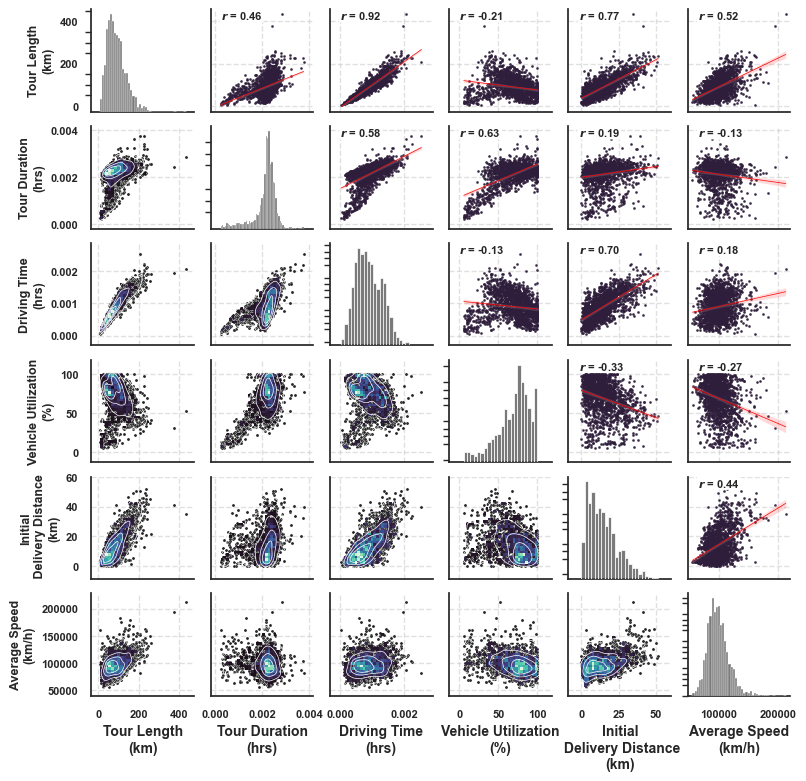

In [30]:
# Import necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from scipy import stats

# Set theme
# sns.set_theme(palette='mako', rc={'figure.figsize':(7.8, 7.8)})
# sns.set()
mpl.rc('font', weight='bold')

# Adjust the size of ticks
mpl.rc('xtick', labelsize=8)
mpl.rc('ytick', labelsize=8)

# Define the data
data = bc[['Tour Length (km)', 'Tour Duration (hrs)', 'Driving Time (hrs)','Vehicle Utilization (%)', 'Initial Delivery Distance (km)', 'Average Speed (km/h)']]

# Rename the columns for better readability
data.columns = ['Tour Length\n(km)', 'Tour Duration\n(hrs)', 'Driving Time\n(hrs)',
                'Vehicle Utilization\n(%)', 'Initial\n Delivery Distance\n(km)', 
                'Average Speed\n(km/h)']
data['Vehicle Utilization\n(%)'] *= 100

# Create a PairGrid
g = sns.PairGrid(data, height=1.66, aspect=1.41, diag_sharey=False)

# Map a histogram to the diagonal
g.map_diag(sns.histplot, color=".3", kde=False)

# For the upper side, use regplot to create a scatterplot with a regression line
def regplot(x, y, **kwargs):
    sns.regplot(x=x, y=y, ci=95,scatter_kws={'s':1, 'rasterized': True}, line_kws={'color': 'red', 'linewidth': 0.5}, **kwargs)
    
    r, _ = stats.pearsonr(x, y)
    ax = plt.gca()
    ax.annotate(f'$r$ = {r:.2f}', xy=(.1, .9), xycoords=ax.transAxes, 
            bbox=dict(boxstyle="round,pad=0.1", ec="white", fc="white", lw=0.01), fontsize=8)

    ax.minorticks_on()
    ax.grid(True, linestyle='--', alpha=0.6)

g.map_upper(regplot)

# For the lower side
def plot_lower(x, y, **kwargs):
    sns.scatterplot(x=x, y=y, s=5, color=".15", rasterized=True)
    sns.histplot(x=x, y=y, bins=30, pthresh=.1, cmap="mako")
    sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=0.5)
    ax = plt.gca()
    ax.minorticks_on()
    ax.grid(True, linestyle='--', alpha=0.6)

g.map_lower(plot_lower)

# Adjust the font size of the labels
for i in range(len(data.columns)):
    for j in range(len(data.columns)):
        xlabel = g.axes[i][j].get_xlabel()
        ylabel = g.axes[i][j].get_ylabel()
        
        if xlabel in data.columns:
            g.axes[i][j].set_xlabel(xlabel, fontsize=10, fontweight='bold')
        if ylabel in data.columns:
            g.axes[i][j].set_ylabel(ylabel, fontsize=9, fontweight='bold')

# Remove y ticks from the histograms on the diagonal
for ax in g.diag_axes:
    ax.yaxis.set_ticks([])

# Adjust figure size
g.fig.set_size_inches(7.8, 7.8)

# Save the figure
g.savefig("multivariate_visualization_neu_2.png", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


In [31]:
sns.set()
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

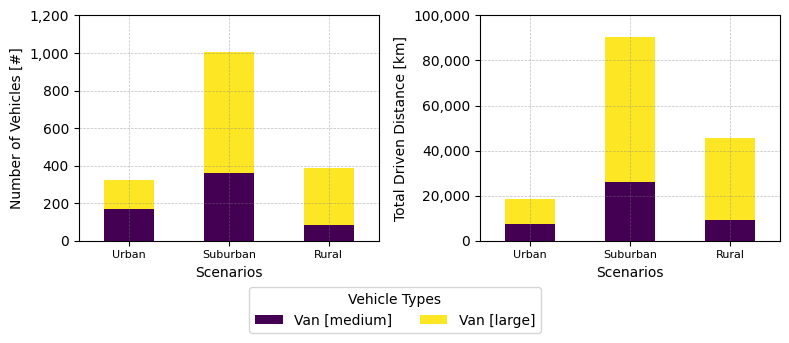

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.ticker as mticker

# Group by 'main_area_type' and aggregate data
aggregated_df = bc.groupby(['area_type_agg', "veh_size"]).agg({
    'vehicle_id': 'count',
    'Tour Length (km)': 'sum'
})

# Calculate total 'Tour Length (km)' per scenario
total_tour_length = bc.groupby('area_type_agg')['Tour Length (km)'].sum().rename('Total Tour Length (km)')

# Merge the total back into the aggregated DataFrame
aggregated_df = aggregated_df.join(total_tour_length, on='area_type_agg')

# Round the values to 2 decimal places
aggregated_df = aggregated_df.round(2)

# # Rename the scenarios for clarity
# scenario_rename = {'bc': 'Baseline', 'rural': 'RCLMD', 'full': 'FCLMD'}
# aggregated_df['scenario'] = aggregated_df['scenario'].map(scenario_rename)

# Assuming aggregated_df is your DataFrame
# Ensure the index is reset for easier plotting
aggregated_df = aggregated_df.reset_index()



# Order the scenarios as per your requirement
scenario_order = ['Urban', 'Suburban', 'Rural']
aggregated_df = aggregated_df[aggregated_df['area_type_agg'].isin(scenario_order)]
aggregated_df['area_type_agg'] = pd.Categorical(aggregated_df['area_type_agg'], categories=scenario_order, ordered=True)
aggregated_df.sort_values('area_type_agg', inplace=True)




# Creating subplots
fig, axs = plt.subplots(1, 2, figsize=(8,3))

# Plot for the number of vehicles
vehicle_count_plot = aggregated_df.pivot(index='area_type_agg', columns='veh_size', values='vehicle_id')
vehicle_count_plot.plot(kind='bar', stacked=True, ax=axs[0], cmap = "viridis")
axs[0].set_ylabel('Number of Vehicles [#]', fontsize=10)
axs[0].set_xlabel('Scenarios', fontsize=10)
axs[0].set_xticklabels(vehicle_count_plot.index, rotation=0, fontsize=10)
axs[0].set_ylim(0 , 1200)

axs[0].set_xticklabels(['Urban', 'Suburban', 'Rural'], rotation=0, fontsize=8)
axs[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Plot for the total driven distance
tour_length_plot = aggregated_df.pivot(index='area_type_agg', columns='veh_size', values='Tour Length (km)')
tour_length_plot.plot(kind='bar', stacked=True, ax=axs[1] , cmap = "viridis")
axs[1].set_ylabel('Total Driven Distance [km]', fontsize=10)
axs[1].set_xlabel('Scenarios', fontsize=10)
axs[1].set_xticklabels(vehicle_count_plot.index, rotation=0, fontsize=10)
axs[1].set_ylim(0 , 100000)
axs[1].set_xticklabels(['Urban', 'Suburban', 'Rural'], rotation=0, fontsize=8)
axs[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))


# # Unified legend below the plots
handles, labels = axs[0].get_legend_handles_labels()

# labels = ["Van [<2t]", "Van [>2t]", "Semi [10-20t]", "Truck [<10t]"]

# Modified labels list to switch 'Semi' and 'Truck'
labels = ["Van [medium]", "Van [large]"]


fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.15), title="Vehicle Types", fontsize=10, ncol=len(labels))


# Remove individual legends
axs[0].get_legend().remove()
axs[1].get_legend().remove()

plt.tight_layout()

# Reduce the visibility of the grid
axs[0].grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5, zorder = 100)
axs[1].grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5, zorder = 100)

# plt.savefig('veh_distance_comparison.png', dpi=fig.dpi)
plt.savefig("veh_distance_comparison.pdf", format='pdf', dpi=300 , bbox_inches='tight')
plt.show()


In [33]:

# Angenommen, 'vans' ist Ihr DataFrame

# Summen und Mittelwerte nach 'area_type_3' berechnen
grouped = bc.groupby('area_type_agg').agg({
    'service_num': ['sum', 'mean'],
    'Tour Length (km)': ['sum', 'mean'],
    'deliveries': ['sum', 'mean'],
    'Vehicle Utilization (%)': ['mean'],  # Sum makes no sense for percentages
    'deliveries_per_stop': ['mean'],  # Sum makes no sense for factors
    'Tour Duration (hrs)': ['sum', 'mean'],
    'Driving Time (hrs)': ['sum', 'mean'],
    'Average Speed (km/h)': ['mean'],  # Sum makes no sense for speed

})

# Ergebnis anzeigen
grouped.columns = ['_'.join(col).strip() for col in grouped.columns.values]
grouped.reset_index(inplace=True)
grouped

,area_type_agg,service_num_sum,service_num_mean,Tour Length (km)_sum,Tour Length (km)_mean,deliveries_sum,deliveries_mean,Vehicle Utilization (%)_mean,deliveries_per_stop_mean,Tour Duration (hrs)_sum,Tour Duration (hrs)_mean,Driving Time (hrs)_sum,Driving Time (hrs)_mean,Average Speed (km/h)_mean
0,Rural,22962,59.641558,45758.690759,118.853742,41698.0,108.306494,0.610456,1.957952,0.818046,0.002125,0.418326,0.001087,108765.731189
1,Suburban,54882,54.500497,90634.330039,90.004300,131989.0,131.071500,0.697785,2.978874,2.152290,0.002137,0.908189,0.000902,99404.261504
2,Urban,14989,46.405573,18514.743063,57.321186,50031.0,154.894737,0.774064,4.488082,0.687870,0.002130,0.217582,0.000674,85262.049269


In [34]:
# sns.set_theme(style='white', palette='mako', rc={'figure.figsize':(7.8, 7.8)})


# mpl.rc('font', weight='bold')

# # Adjust the size of ticks
# mpl.rc('xtick', labelsize=8)
# mpl.rc('ytick', labelsize=8)

sns.set()
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

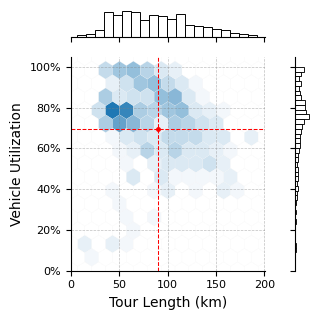

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm

def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip('#')
    return [int(hex_color[i:i+2], 16) for i in (0, 2, 4)]

def get_color_gradient(hex_color, n_shades):
    color_rgb = np.array(hex_to_rgb(hex_color))
    gradient = [color_rgb + (255 - color_rgb) * i / (n_shades - 1) for i in range(n_shades)]
    gradient = np.clip(gradient, 0, 255).astype(int)
    return gradient

colors = {
    'Urban': '#808080',
    'Suburban': '#1f78b4',
    'Rural': '#33a02c',
    'Total': '#fde725'  # Gelb aus der Viridis-Farbkarte
}

n_shades = 20
gradients = {name: get_color_gradient(color, n_shades)[::-1] for name, color in colors.items()}

gradients_rgb = {name: [(r/255, g/255, b/255) for r, g, b in gradient] for name, gradient in gradients.items()}

def create_transparent_cmap(hex_color, n_shades):
    color_rgb = np.array(hex_to_rgb(hex_color)) / 255.0
    alpha = np.linspace(0, 1, n_shades)
    cmap_colors = np.column_stack([np.tile(color_rgb, (n_shades, 1)), alpha])
    return LinearSegmentedColormap.from_list(f'{hex_color}_cmap', cmap_colors)

urban_cmap = create_transparent_cmap(colors['Urban'], n_shades)
suburban_cmap = create_transparent_cmap(colors['Suburban'], n_shades)
rural_cmap = create_transparent_cmap(colors['Rural'], n_shades)
viridis_yellow_cmap = create_transparent_cmap(colors['Total'], n_shades)

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Convert RGB tuples to matplotlib color format
suburban_gradient = [f'#{r:02x}{g:02x}{b:02x}' for r, g, b in gradients['Suburban']]
suburban_cmap = LinearSegmentedColormap.from_list('suburban_cmap', suburban_gradient, N=n_shades)


vans_rural = bc[bc.area_type_agg =="Suburban"]

# Ensure that the x and y axes are the same for both datasets
x_min, x_max = 0, 201
y_min, y_max = 0, 1.05  # The y-axis range as a fraction

# Calculate the mean values
mean_x = vans_rural['Tour Length (km)'].mean()
mean_y = vans_rural['Vehicle Utilization (%)'].mean()

# Function to format the y-axis labels as percentages without decimals
def to_percent(y, position):
    return f"{int(100 * y)}%"

# Create the percentage formatter
percent_formatter = FuncFormatter(to_percent)

# Set common axis limits
x_lim = (0, x_max)
y_lim = (0, y_max)

# Set a common gridsize
gridsize = 14  # Choose a gridsize that suits your data density

# Plot for the first dataset
g1 = sns.jointplot(
    data=vans_rural[vans_rural["Tour Length (km)"] < 500], 
    x='Tour Length (km)', 
    y='Vehicle Utilization (%)',
    kind='hex', 
    cmap=suburban_cmap, 
    marginal_kws=dict(bins=40, fill=True, color = "white"),
    gridsize=gridsize,
    joint_kws={'extent': x_lim + y_lim, 'edgecolors': 'whitesmoke', 'linewidths': 0.1}
)
g1.fig.set_size_inches(3.3, 3.3)
g1.ax_joint.set_xticks([0, 50, 100, 150, 200, 250])
g1.ax_joint.set_xlim([x_min, x_max])
g1.ax_joint.set_ylim([y_min, y_max])



# Draw dashed lines from the axes to the mean point
g1.ax_joint.axhline(mean_y, ls='--', lw=0.75, color='red')
g1.ax_joint.axvline(mean_x, ls='--', lw=0.75, color='red')

# Highlight the hexagon with the mean x and y values
g1.ax_joint.plot(mean_x, mean_y, '.', markersize=5, color = "red")

# Apply the percentage formatter to the y-axis
g1.ax_joint.yaxis.set_major_formatter(percent_formatter)

# Adjust the tick label size
g1.ax_joint.tick_params(axis='both', which='major', labelsize=8)
# Set the axis label sizes
g1.set_axis_labels('Tour Length (km)', 'Vehicle Utilization', fontsize=10)

# Reduce the visibility of the grid
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.tight_layout()

plt.savefig("suburban-hex.pdf", format='pdf', dpi=300 , bbox_inches='tight')

plt.show()





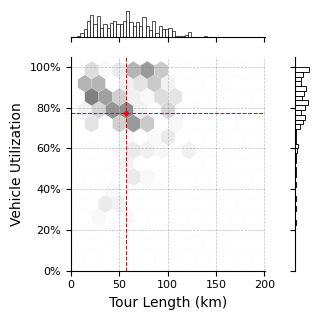

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Convert RGB tuples to matplotlib color format
suburban_gradient = [f'#{r:02x}{g:02x}{b:02x}' for r, g, b in gradients['Urban']]
suburban_cmap = LinearSegmentedColormap.from_list('suburban_cmap', suburban_gradient, N=n_shades)

vans_rural = bc[bc.area_type_agg =="Urban"]

# Ensure that the x and y axes are the same for both datasets
x_min, x_max = 0, 201
y_min, y_max = 0, 1.05  # The y-axis range as a fraction

# Calculate the mean values
mean_x = vans_rural['Tour Length (km)'].mean()
mean_y = vans_rural['Vehicle Utilization (%)'].mean()

# Function to format the y-axis labels as percentages without decimals
def to_percent(y, position):
    return f"{int(100 * y)}%"

# Create the percentage formatter
percent_formatter = FuncFormatter(to_percent)

# Set common axis limits
x_lim = (0, x_max)
y_lim = (0, y_max)

# Set a common gridsize
gridsize = 14  # Choose a gridsize that suits your data density

# Plot for the first dataset
g1 = sns.jointplot(
    data=vans_rural[vans_rural["Tour Length (km)"] < 500], 
    x='Tour Length (km)', 
    y='Vehicle Utilization (%)',
    kind='hex', 
    cmap=suburban_cmap, 
    marginal_kws=dict(bins=40, fill=True, color = "white"),
    gridsize=gridsize,
    joint_kws={'extent': x_lim + y_lim, 'edgecolors': 'whitesmoke', 'linewidths': 0.1}
)
g1.fig.set_size_inches(3.3, 3.3)
g1.ax_joint.set_xticks([0, 50, 100, 150, 200, 250])
g1.ax_joint.set_xlim([x_min, x_max])
g1.ax_joint.set_ylim([y_min, y_max])



# Draw dashed lines from the axes to the mean point
g1.ax_joint.axhline(mean_y, ls='--', lw=0.75, color='red')
g1.ax_joint.axvline(mean_x, ls='--', lw=0.75, color='red')

# Highlight the hexagon with the mean x and y values
g1.ax_joint.plot(mean_x, mean_y, '.', markersize=5, color = "red")

# Apply the percentage formatter to the y-axis
g1.ax_joint.yaxis.set_major_formatter(percent_formatter)

# Adjust the tick label size
g1.ax_joint.tick_params(axis='both', which='major', labelsize=8)
# Set the axis label sizes
g1.set_axis_labels('Tour Length (km)', 'Vehicle Utilization', fontsize=10)

# Reduce the visibility of the grid
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.tight_layout()

plt.savefig("urban-hex.pdf", format='pdf', dpi=300 , bbox_inches='tight')

plt.show()




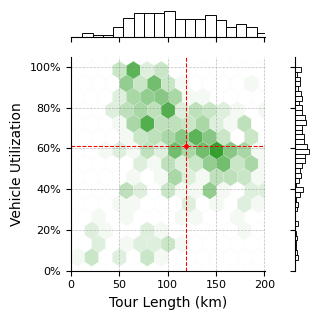

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Convert RGB tuples to matplotlib color format
suburban_gradient = [f'#{r:02x}{g:02x}{b:02x}' for r, g, b in gradients['Rural']]
suburban_cmap = LinearSegmentedColormap.from_list('suburban_cmap', suburban_gradient, N=n_shades)

vans_rural = bc[bc.area_type_agg =="Rural"]

# Ensure that the x and y axes are the same for both datasets
x_min, x_max = 0, 201
y_min, y_max = 0, 1.05  # The y-axis range as a fraction

# Calculate the mean values
mean_x = vans_rural['Tour Length (km)'].mean()
mean_y = vans_rural['Vehicle Utilization (%)'].mean()

# Function to format the y-axis labels as percentages without decimals
def to_percent(y, position):
    return f"{int(100 * y)}%"

# Create the percentage formatter
percent_formatter = FuncFormatter(to_percent)

# Set common axis limits
x_lim = (0, x_max)
y_lim = (0, y_max)

# Set a common gridsize
gridsize = 14  # Choose a gridsize that suits your data density

# Plot for the first dataset
g1 = sns.jointplot(
    data=vans_rural[vans_rural["Tour Length (km)"] < 500], 
    x='Tour Length (km)', 
    y='Vehicle Utilization (%)',
    kind='hex', 
    cmap=suburban_cmap, 
    marginal_kws=dict(bins=40, fill=True, color = "white"),
    gridsize=gridsize,
    joint_kws={'extent': x_lim + y_lim, 'edgecolors': 'whitesmoke', 'linewidths': 0.1}
)
g1.fig.set_size_inches(3.3, 3.3)
g1.ax_joint.set_xticks([0, 50, 100, 150, 200, 250])
g1.ax_joint.set_xlim([x_min, x_max])
g1.ax_joint.set_ylim([y_min, y_max])



# Draw dashed lines from the axes to the mean point
g1.ax_joint.axhline(mean_y, ls='--', lw=0.75, color='red')
g1.ax_joint.axvline(mean_x, ls='--', lw=0.75, color='red')

# Highlight the hexagon with the mean x and y values
g1.ax_joint.plot(mean_x, mean_y, '.', markersize=5, color = "red")

# Apply the percentage formatter to the y-axis
g1.ax_joint.yaxis.set_major_formatter(percent_formatter)

# Adjust the tick label size
g1.ax_joint.tick_params(axis='both', which='major', labelsize=8)
# Set the axis label sizes
g1.set_axis_labels('Tour Length (km)', 'Vehicle Utilization', fontsize=10)

# Reduce the visibility of the grid
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.tight_layout()

plt.savefig("rural-hex.pdf", format='pdf', dpi=300 , bbox_inches='tight')

plt.show()




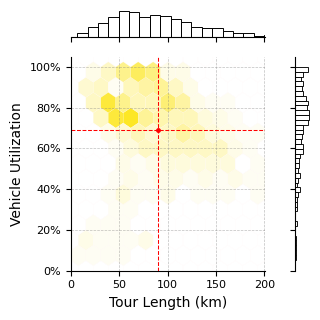

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Convert RGB tuples to matplotlib color format
suburban_gradient = [f'#{r:02x}{g:02x}{b:02x}' for r, g, b in gradients['Total']]
suburban_cmap = LinearSegmentedColormap.from_list('suburban_cmap', suburban_gradient, N=n_shades)


vans_rural = bc

# Ensure that the x and y axes are the same for both datasets
x_min, x_max = 0, 201
y_min, y_max = 0, 1.05  # The y-axis range as a fraction

# Calculate the mean values
mean_x = vans_rural['Tour Length (km)'].mean()
mean_y = vans_rural['Vehicle Utilization (%)'].mean()

# Function to format the y-axis labels as percentages without decimals
def to_percent(y, position):
    return f"{int(100 * y)}%"

# Create the percentage formatter
percent_formatter = FuncFormatter(to_percent)

# Set common axis limits
x_lim = (0, x_max)
y_lim = (0, y_max)

# Set a common gridsize
gridsize = 13  # Choose a gridsize that suits your data density

# Plot for the first dataset
g1 = sns.jointplot(
    data=vans_rural[vans_rural["Tour Length (km)"] < 500], 
    x='Tour Length (km)', 
    y='Vehicle Utilization (%)',
    kind='hex', 
    cmap=suburban_cmap, 
    marginal_kws=dict(bins=40, fill=True, color = "white"),
    gridsize=gridsize,
    joint_kws={'extent': x_lim + y_lim, 'edgecolors': 'snow', 'linewidths': 0.1}
)
g1.fig.set_size_inches(3.3, 3.3)
g1.ax_joint.set_xticks([0, 50, 100, 150, 200, 250])
g1.ax_joint.set_xlim([x_min, x_max])
g1.ax_joint.set_ylim([y_min, y_max])



# Draw dashed lines from the axes to the mean point
g1.ax_joint.axhline(mean_y, ls='--', lw=0.75, color='red')
g1.ax_joint.axvline(mean_x, ls='--', lw=0.75, color='red')

# Highlight the hexagon with the mean x and y values
g1.ax_joint.plot(mean_x, mean_y, '.', markersize=5, color = "red")

# Apply the percentage formatter to the y-axis
g1.ax_joint.yaxis.set_major_formatter(percent_formatter)

# Adjust the tick label size
g1.ax_joint.tick_params(axis='both', which='major', labelsize=8)
# Set the axis label sizes
g1.set_axis_labels('Tour Length (km)', 'Vehicle Utilization', fontsize=10)

# Reduce the visibility of the grid
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.tight_layout()

plt.savefig("total-hex.pdf", format='pdf', dpi=300 , bbox_inches='tight')

plt.show()




C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_27808\246673948.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)  # Hide individual legends on each subplot
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_27808\246673948.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)  # Hide individual legends on each subplot
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_27808\246673948.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)  # Hide individual legends on each subplot
C:\Users\bienzeisler\AppData\Local\Temp\ipy

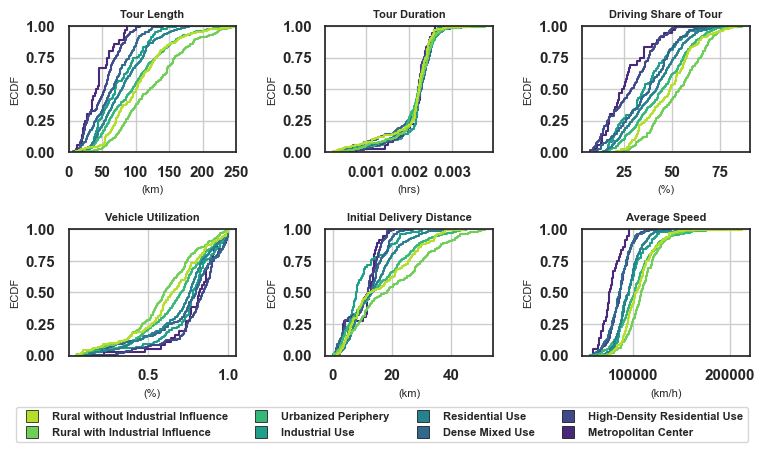

In [39]:
# Map the numbers to the area descriptions
bc['main_area_type_desc'] = bc['main_area_type'].astype(str).map(category_dict)

# Select only the necessary columns
bc_selected = bc[['Tour Length (km)', 'Tour Duration (hrs)', 'Driving Share of Tour (%)',
                  'Vehicle Utilization (%)', 'Initial Delivery Distance (km)', 
                  'Average Speed (km/h)','main_area_type_desc']]

sns.set_theme(style='white', palette='mako', rc={'figure.figsize':(7.8, 7.8)})

mpl.rc('font', weight='bold')

# Create a 3x2 subplot layout
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(7.8, 4.25))

# Define the titles for the plots
plot_titles = ['Tour Length', 'Tour Duration', 
               'Driving Share of Tour', 'Vehicle Utilization', 
               'Initial Delivery Distance', 'Average Speed']

# Define the DataFrame and x-axis column names for each subplot
x_axes_cols = ['Tour Length (km)', 'Tour Duration (hrs)', 
               'Driving Share of Tour (%)', 'Vehicle Utilization (%)', 
               'Initial Delivery Distance (km)', 'Average Speed (km/h)']


# Define the x-axis labels
x_axis_labels = ['(km)', '(hrs)', 
                 '(%)', '(%)', 
                 '(km)', '(km/h)']

# Define the hue column name for the ECDF plot
hue_col_name = 'main_area_type_desc'

# Loop through each subplot and plot the corresponding ECDF
for i, ax in enumerate(axes.flat):
    sns.ecdfplot(data=bc_selected, x=x_axes_cols[i], ax=ax , hue=hue_col_name, palette=category_color_dict)
    ax.set_title(plot_titles[i], fontsize= 8, weight = 'bold')
    ax.set_xlabel(x_axis_labels[i], fontsize= 8)  # Adding x-axis label
    ax.set_ylabel('ECDF', fontsize= 8)
    ax.grid(True) 
    ax.legend().set_visible(False)  # Hide individual legends on each subplot
    
    # Set x-axis ticks for specific plots
    if plot_titles[i] == 'Tour Length':
        ax.set_xticks(range(0, 251, 50))
        ax.set_xlim(0, 250)
    elif plot_titles[i] == 'Driving Time':
        ax.set_xticks(range(0, 8, 1))    

    
# # Create a custom legend outside the subplots
custom_legend_labels = list(category_color_dict.keys())[::-1] # Replace with actual legend labels
# fig.legend(custom_legend_labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.035), fontsize= 8)

# Create a custom legend outside the subplots
handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=v, markeredgewidth=0.5, markeredgecolor='black', markersize=8) for v in reversed(palette_dict.values())]
fig.legend(handles, custom_legend_labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.035), fontsize= 8)

# Adjust the layout for better spacing
plt.tight_layout(rect=[0, 0.001, 1, 0.9999])  # Include space for the custom legend at the bottom

# Save the figure
# plt.savefig("diff_distribution_visualization.pdf", dpi=300, bbox_inches='tight')
# Show the plots
plt.show()

In [40]:
sns.set_theme(style='white', palette='mako', rc={'figure.figsize':(7.8, 7.8)})


mpl.rc('font', weight='bold')

# Adjust the size of ticks
mpl.rc('xtick', labelsize=8)
mpl.rc('ytick', labelsize=8)

# sns.set()
# import matplotlib as mpl
# mpl.rcParams.update(mpl.rcParamsDefault)

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_27808\1992757899.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bc_selected, y=y_axes_cols[i], x=x_axis_col, ax=ax,
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_27808\1992757899.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)  # Hide individual legends on each subplot
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_27808\1992757899.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bc_selected, y=y_axes_cols[i], x=x_axis_col, ax=ax,
C:\Users\bienzeisler\App

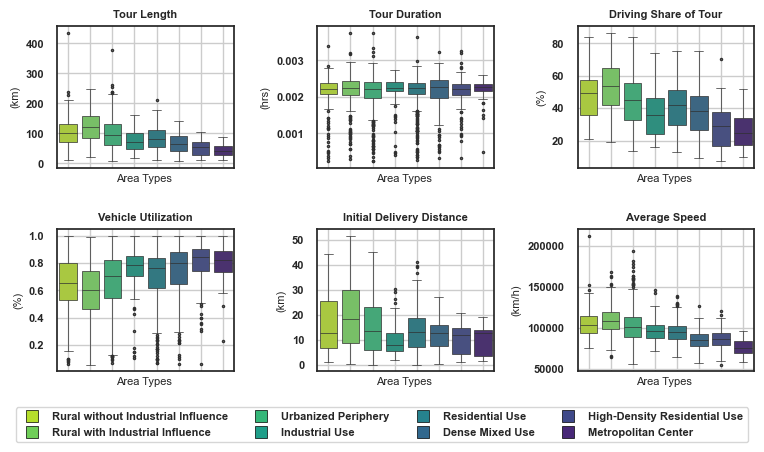

In [41]:
# Create a 2x3 subplot layout for the boxplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(7.8, 4.25))

# Define a custom ordering for the x-axis
order = list(reversed(palette_dict.keys()))

# Define the titles for the plots
plot_titles = ['Tour Length', 'Tour Duration', 
               'Driving Share of Tour', 'Vehicle Utilization', 
               'Initial Delivery Distance', 'Average Speed']

# Define the DataFrame and y-axis column names for each subplot
y_axes_cols = ['Tour Length (km)', 'Tour Duration (hrs)', 
               'Driving Share of Tour (%)', 'Vehicle Utilization (%)', 
               'Initial Delivery Distance (km)', 'Average Speed (km/h)']

# Define the x-axis labels
y_axis_labels = ['(km)', '(hrs)', 
                 '(%)', '(%)', 
                 '(km)', '(km/h)']

# Define the x-axis column name for the boxplot
x_axis_col = 'main_area_type_desc'

# Loop through each subplot and plot the corresponding boxplot
for i, ax in enumerate(axes.flat):
    sns.boxplot(data=bc_selected, y=y_axes_cols[i], x=x_axis_col, ax=ax, 
                palette=palette_dict, order=order, linewidth=0.5, flierprops={"marker": "." , "markersize": 3})    
    
    ax.set_title(plot_titles[i], fontsize= 8, weight = 'bold')
    ax.set_xlabel('')  # Remove x-axis label
    ax.set_ylabel(y_axis_labels[i], fontsize= 8)  # Adding x-axis label
    ax.tick_params(axis='x', labelbottom=False)  # Remove x-axis labels
    ax.grid(True) 
    ax.legend().set_visible(False)  # Hide individual legends on each subplot
    ax.set_xlabel("Area Types \n", fontsize= 8)  # Adding x-axis label


# Create a custom legend outside the subplots
handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=v, markeredgewidth=0.5, markeredgecolor='black', markersize=8) for v in reversed(palette_dict.values())]
fig.legend(handles, custom_legend_labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.035), fontsize= 8)

# Adjust the layout for better spacing
plt.tight_layout(rect=[0, 0.001, 1, 0.9999])  # Include space for the custom legend at the bottom

# plt.savefig("box_distribution_visualization.pdf", dpi=300, bbox_inches='tight')
# Show the plots
plt.show()

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_27808\1502990808.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


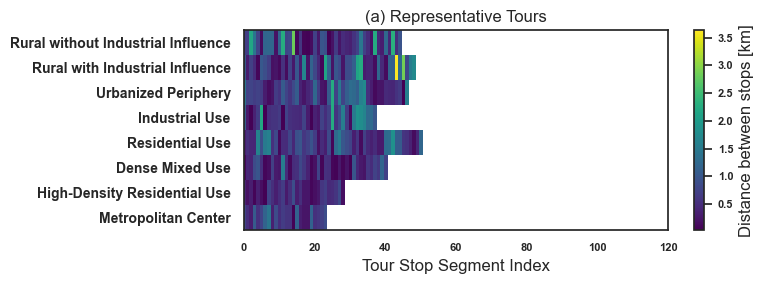

In [42]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import ast
from scipy.spatial.distance import cdist


if isinstance(bc['service_dists'].iloc[0], str):
    bc['service_dists'] = bc['service_dists'].apply(ast.literal_eval)

# Schritt 1: Distanzen zwischen Stopps je Tour berechnen
def get_stop_segments(row):
    d = sorted(row['service_dists'].values())
    return [d[i+1] - d[i] for i in range(len(d)-1)] if len(d) > 1 else []

bc['stop_segments'] = bc.apply(get_stop_segments, axis=1)

# Schritt 2: L2-Medoid finden (Padding mit 0)
def find_l2_medoid(tour_segments):
    max_len = max(len(t) for t in tour_segments)
    padded = np.array([t + [0]*(max_len - len(t)) for t in tour_segments])
    dists = cdist(padded, padded, metric='euclidean')
    total_dist = np.sum(dists, axis=1)
    return tour_segments[np.argmin(total_dist)]

# Schritt 3: Repräsentative Tour pro Raumtyp bestimmen
area_representatives = {}
for area in bc['main_area_description'].unique():
    group = bc[bc['main_area_description'] == area]
    segments = [
        s for s in group['stop_segments']
        if isinstance(s, list) and len(s) >= 1 and all(isinstance(x, (int, float)) for x in s)
    ]
    if len(segments) < 2:
        print(f"⚠️ Überspringe '{area}' (nicht genug gültige Touren)")
        continue
    rep = find_l2_medoid(segments)
    area_representatives[area] = rep

def plot_representative_tours_with_stats(area_representatives, bc):
    sort_order = [
        "Rural without Industrial Influence",
        "Rural with Industrial Influence",
        "Urbanized Periphery",
        "Industrial Use",
        "Residential Use",
        "Dense Mixed Use",
        "High-Density Residential Use",
        "Metropolitan Center"
    ]

    reps_sorted = []
    y_labels = []
    tour_lengths = []
    avg_load_factors = []

    for k in sort_order:
        if k in area_representatives:
            rep = area_representatives[k]
            reps_sorted.append(rep)
            y_labels.append(k)
            tour_lengths.append(np.round(np.sum(rep), 1))  # km

            # Durchschnittliche Auslastung aus bc
            avg_load = bc[bc["main_area_description"] == k]["Vehicle Utilization (%)"].mean()
            avg_load_factors.append(np.round(avg_load * 100, 1))  # Prozent

    max_len = max(len(r) for r in reps_sorted)
    padded = np.array([r + [np.nan]*(max_len - len(r)) for r in reps_sorted])

    fig, ax = plt.subplots(figsize=(8, 3))
    cmap = cm.get_cmap('viridis')
    norm = mcolors.Normalize(vmin=np.nanmin(padded), vmax=np.nanmax(padded))
    cax = ax.imshow(padded, aspect='auto', cmap=cmap, norm=norm)

    # ax.set_xlim(-5,50)

    ax.set_yticks(np.arange(len(reps_sorted)))
    ax.set_yticklabels(y_labels, fontsize=10)
    ax.set_xlabel('Tour Stop Segment Index')
    ax.set_title('(a) Representative Tours')
    ax.set_xlim(0, 120)
    # # Zusatzinfos rechts daneben schreiben
    # for i, (length, load) in enumerate(zip(tour_lengths, avg_load_factors)):
    #     label = f"{load:.1f}%"
    #     ax.text(padded.shape[1] + 1, i, label, va='center', fontsize=8, color='black')

    # Farbe + Layout
    plt.colorbar(cax, label='Distance between stops [km]', ax=ax)
    plt.tight_layout()
    fig.savefig("representative_tours.pdf", dpi=300, bbox_inches='tight', format='pdf')
    plt.show()


plot_representative_tours_with_stats(area_representatives, bc)


c:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\matsim-py\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_27808\2570270225.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('magma')


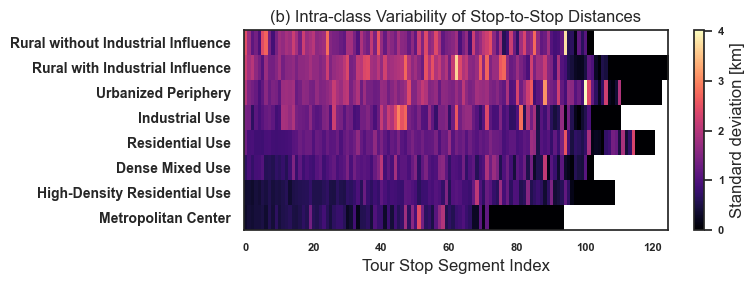

In [43]:
sort_order = [
    "Rural without Industrial Influence",
    "Rural with Industrial Influence",
    "Urbanized Periphery",
    "Industrial Use",
    "Residential Use",
    "Dense Mixed Use",
    "High-Density Residential Use",
    "Metropolitan Center"
]

std_matrix = []
valid_labels = []

# Finde globale max-Länge über alle Raumtypen
global_max_len = 0
for k in sort_order:
    group = bc[bc["main_area_description"] == k]
    segments = [s for s in group['stop_segments'] if isinstance(s, list) and len(s) >= 1]
    if len(segments) >= 2:
        local_max = max(len(t) for t in segments)
        global_max_len = max(global_max_len, local_max)

# Berechne gepaddete STD-Vektoren
for k in sort_order:
    group = bc[bc["main_area_description"] == k]
    segments = [s for s in group['stop_segments'] if isinstance(s, list) and len(s) >= 1]
    if len(segments) < 2:
        continue
    padded = np.array([t + [np.nan]*(global_max_len - len(t)) for t in segments])
    std = np.nanstd(padded, axis=0)
    std_matrix.append(std)
    valid_labels.append(k)

# In Heatmap umwandeln
std_padded = np.vstack(std_matrix)

fig, ax = plt.subplots(figsize=(8, 3))
cmap = cm.get_cmap('magma')
norm = mcolors.Normalize(vmin=0, vmax=np.nanmax(std_padded))
cax = ax.imshow(std_padded, aspect='auto', cmap=cmap, norm=norm)

ax.set_yticks(np.arange(len(valid_labels)))
ax.set_yticklabels(valid_labels, fontsize=10)
ax.set_xlabel('Tour Stop Segment Index')
ax.set_title("(b) Intra-class Variability of Stop-to-Stop Distances")
plt.colorbar(cax, label='Standard deviation [km]', ax=ax)
plt.tight_layout()
fig.savefig("tour_segment_variability.pdf", dpi=300, bbox_inches='tight', format='pdf')
plt.show()



In [44]:
bc['Service Duration'] = bc['Service Duration'] / 3600

In [45]:
import pandas as pd

# Strukturierter KPI-Block mit Beschreibung + Einheit
kpi_structure = {
    "Temporal Metrics": {
        "Tour Duration (hrs)": "Tour Duration [hrs]",
        "Driving Time (hrs)": "Driving Time [hrs]",
        "Service Duration": "Total Delivery Duration [hrs]"
    },
    "Tour Structure": {
        "Tour Length (km)": "Tour Length [km]",
        "Initial Delivery Distance (km)": "Initial Delivery Distance [km]",
        "service_num": "Number of Stops [#]",
        "Mean Distance Between Stops (km)": "Mean Distance Between Stops [km]",
        "max_dist_wo_init": "Maximum Segment Distance [km]",
        "delivery_area_km2": "Delivery Area [km²]",
        "Driving Share of Tour (%)": "Driving Share [%]",
        "Average Speed (km/h)": "Average Speed [km/h]",
        # wird später als Sonderfall über len() je Gruppe hinzugefügt
    },
    "Delivery Metrics": {
        "deliveries": "Deliveries [#]",        
        "deliveries_per_stop": "Deliveries per Stop [#]",
        "missed deliveries": "Missed Deliveries [#]",
        "vehicle_deliver_factor": "Vehicle Delivery Ration [%]",       
        "b2b_ration": "B2B Ratio [%]"
    },
    "Load Metrics": {
        "total_weight": "Total Weight [kg]",
        "avg_weight_per_parcel": "Avg. Weight per Parcel [kg]",
        "Vehicle Utilization (%)": "Vehicle Utilization [%]"
    },
    "Cost Metrics": {
        "vehicle_cost": "Total Vehicle Cost [€]",
        "vehicle_fix_cost": "Fixed Vehicle Cost [€]",
        "vehicle_km_cost": "Distance-based Cost [€]",
        "overtime_cost": "Overtime Cost [€]"
    }
}

# Nur numerische Spalten extrahieren, die auch im DataFrame vorhanden sind
kpi_numeric = {
    group: {
        col: label for col, label in metrics.items()
        if col in bc.columns and pd.api.types.is_numeric_dtype(bc[col])
    } for group, metrics in kpi_structure.items()
}
kpi_columns = [col for group in kpi_numeric.values() for col in group]

# Gruppierung + Aggregation
summary_df = bc.groupby("main_area_description")[kpi_columns].agg(["mean", "std", "median", "count"])

# Spaltennamen ersetzen (Ebene 0)
renaming_dict = {
    col: label for group in kpi_numeric.values() for col, label in group.items()
}
summary_df.rename(columns=renaming_dict, level=0, inplace=True)

# Total Vehicles als eigene Spalte in "Tour Structure"
vehicle_counts = bc.groupby("main_area_description").size().rename("Total Vehicles [#]")
summary_df[("Total Vehicles [#]", "count")] = vehicle_counts
summary_df[("Total Vehicles [#]", "mean")] = vehicle_counts  # fix für Kompatibilität
summary_df[("Total Vehicles [#]", "std")] = float("nan")
summary_df[("Total Vehicles [#]", "median")] = vehicle_counts

# Ergebnis: summary_df enthält alle strukturierten, numerischen KPIs + Fahrzeuganzahl
summary_df


Tour Duration [hrs]                      \
                                                  mean       std    median   
main_area_description                                                        
Dense Mixed Use                               0.002109  0.000562  0.002284   
High-Density Residential Use                  0.002144  0.000419  0.002212   
Industrial Use                                0.002166  0.000445  0.002255   
Metropolitan Center                           0.002157  0.000394  0.002267   
Residential Use                               0.002139  0.000467  0.002255   
Rural with Industrial Influence               0.002151  0.000488  0.002251   
Rural without Industrial Influence            0.002077  0.000552  0.002221   
Urbanized Periphery                           0.002129  0.000481  0.002213   

                                         Driving Time [hrs]            \
                                   count               mean       std   
main_area_description                                                   
Dense Mixed Use                      148           0.000768  0.000349   
High-Density Residential Use         139           0.000600  0.000287   
Industrial Use                       102           0.000782  0.000335   
Metropolitan Center                   36           0.000571  0.000281   
Residential Use                      439           0.000867  0.000362   
Rural with Industrial Influence      249           0.001137  0.000403   
Rural without Industrial Influence   136           0.000995  0.000399   
Urbanized Periphery                  466           0.000961  0.000404   

                                                    \
                                      median count   
main_area_description                                
Dense Mixed Use                     0.000753   148   
High-Density Residential Use        0.000578   139   
Industrial Use                      0.000751   102   
Metropolitan Center                 0.000513    36   
Residential Use                     0.000841   439   
Rural with Industrial Influence     0.001132   249   
Rural without Industrial Influence  0.000938   136   
Urbanized Periphery                 0.000928   466   

                                   Total Delivery Duration [hrs]            \
                                                            mean       std   
main_area_description                                                        
Dense Mixed Use                                         4.827050  1.603736   
High-Density Residential Use                            5.561483  1.362387   
Industrial Use                                          4.982821  1.381676   
Metropolitan Center                                     5.710779  1.278298   
Residential Use                                         4.579283  1.417199   
Rural with Industrial Influence                         3.651554  1.286340   
Rural without Industrial Influence                      3.895257  1.429714   
Urbanized Periphery                                     4.206457  1.340087   

                                    ... Distance-based Cost [€]        \
                                    ...                  median count   
main_area_description               ...                                 
Dense Mixed Use                     ...               24.657345   148   
High-Density Residential Use        ...               20.458118   139   
Industrial Use                      ...               26.504448   102   
Metropolitan Center                 ...               16.397142    36   
Residential Use                     ...               30.083565   439   
Rural with Industrial Influence     ...               45.407316   249   
Rural without Industrial Influence  ...               38.249451   136   
Urbanized Periphery                 ...               35.755804   466   

                                   Overtime Cost [€]                        \
                                    

In [46]:
mean_df = summary_df.xs("mean", axis=1, level=1)

# Optional: Runden für bessere Lesbarkeit
mean_df = mean_df.round(2)

mean_df.to_csv("summary_df_detail.csv", index=True)

In [47]:
# Gruppierte Meta-Aggregate nach Raumtyp (main_area_description)
meta_grouped = bc.groupby("main_area_description").agg({
    "veh_size": lambda x: (x == "m").sum(),   # Anzahl Medium
}).rename(columns={"veh_size": "Total Vehicles m [#]"})

# Weitere Aggregationen hinzufügen
meta_grouped["Total Vehicles l [#]"] = bc.groupby("main_area_description")["veh_size"].apply(lambda x: (x == "l").sum())
meta_grouped["Total Vehicles all [#]"] = bc.groupby("main_area_description").size()
meta_grouped["Total Tour Length [km]"] = bc.groupby("main_area_description")["Tour Length (km)"].sum()
meta_grouped["Total Number of Stops [#]"] = bc.groupby("main_area_description")["service_num"].sum()
meta_grouped["Total Number of Deliveries [#]"] = bc.groupby("main_area_description")["deliveries"].sum()

# Ergebnis sortieren (optional)
meta_grouped = meta_grouped[
    ["Total Vehicles m [#]", "Total Vehicles l [#]", "Total Vehicles all [#]",
     "Total Tour Length [km]", "Total Number of Stops [#]", "Total Number of Deliveries [#]"]
]
meta_grouped.to_csv("meta_grouped_detailed.csv", index=True)

In [48]:
import pandas as pd

# Strukturierter KPI-Block mit Beschreibung + Einheit
kpi_structure = {
    "Temporal Metrics": {
        "Tour Duration (hrs)": "Tour Duration [hrs]",
        "Driving Time (hrs)": "Driving Time [hrs]",
        "Service Duration": "Total Delivery Duration [hrs]"
    },
    "Tour Structure": {
        "Tour Length (km)": "Tour Length [km]",
        "Initial Delivery Distance (km)": "Initial Delivery Distance [km]",
        "service_num": "Number of Stops [#]",
        "Mean Distance Between Stops (km)": "Mean Distance Between Stops [km]",
        "max_dist_wo_init": "Maximum Segment Distance [km]",
        "delivery_area_km2": "Delivery Area [km²]",
        "Driving Share of Tour (%)": "Driving Share [%]",
        "Average Speed (km/h)": "Average Speed [km/h]",
        # wird später als Sonderfall über len() je Gruppe hinzugefügt
    },
    "Delivery Metrics": {
        "deliveries": "Deliveries [#]",        
        "deliveries_per_stop": "Deliveries per Stop [#]",
        "missed deliveries": "Missed Deliveries [#]",
        "vehicle_deliver_factor": "Vehicle Delivery Ration [%]",       
        "b2b_ration": "B2B Ratio [%]"
    },
    "Load Metrics": {
        "total_weight": "Total Weight [kg]",
        "avg_weight_per_parcel": "Avg. Weight per Parcel [kg]",
        "Vehicle Utilization (%)": "Vehicle Utilization [%]"
    },
    "Cost Metrics": {
        "vehicle_cost": "Total Vehicle Cost [€]",
        "vehicle_fix_cost": "Fixed Vehicle Cost [€]",
        "vehicle_km_cost": "Distance-based Cost [€]",
        "overtime_cost": "Overtime Cost [€]"
    }
}

# Nur numerische Spalten extrahieren, die auch im DataFrame vorhanden sind
kpi_numeric = {
    group: {
        col: label for col, label in metrics.items()
        if col in bc.columns and pd.api.types.is_numeric_dtype(bc[col])
    } for group, metrics in kpi_structure.items()
}
kpi_columns = [col for group in kpi_numeric.values() for col in group]

# Gruppierung + Aggregation
summary_df = bc.groupby("area_type_agg")[kpi_columns].agg(["mean", "std", "median", "count"])

# Spaltennamen ersetzen (Ebene 0)
renaming_dict = {
    col: label for group in kpi_numeric.values() for col, label in group.items()
}
summary_df.rename(columns=renaming_dict, level=0, inplace=True)

# Total Vehicles als eigene Spalte in "Tour Structure"
vehicle_counts = bc.groupby("area_type_agg").size().rename("Total Vehicles [#]")
summary_df[("Total Vehicles [#]", "count")] = vehicle_counts
summary_df[("Total Vehicles [#]", "mean")] = vehicle_counts  # fix für Kompatibilität
summary_df[("Total Vehicles [#]", "std")] = float("nan")
summary_df[("Total Vehicles [#]", "median")] = vehicle_counts

# Ergebnis: summary_df enthält alle strukturierten, numerischen KPIs + Fahrzeuganzahl
summary_df.to_csv("summary_df_area_type_agg.csv", index=True)


In [49]:
mean_df = summary_df.xs("mean", axis=1, level=1)

# Optional: Runden für bessere Lesbarkeit
mean_df = mean_df.round(2)

mean_df.to_csv("summary_df_agg.csv", index=True)

In [50]:
# Gruppierte Meta-Aggregate nach Raumtyp (main_area_description)
meta_grouped = bc.groupby("area_type_agg").agg({
    "veh_size": lambda x: (x == "m").sum(),   # Anzahl Medium
}).rename(columns={"veh_size": "Total Vehicles m [#]"})

# Weitere Aggregationen hinzufügen
meta_grouped["Total Vehicles l [#]"] = bc.groupby("area_type_agg")["veh_size"].apply(lambda x: (x == "l").sum())
meta_grouped["Total Vehicles all [#]"] = bc.groupby("area_type_agg").size()
meta_grouped["Total Tour Length [km]"] = bc.groupby("area_type_agg")["Tour Length (km)"].sum()
meta_grouped["Total Number of Stops [#]"] = bc.groupby("area_type_agg")["service_num"].sum()
meta_grouped["Total Number of Deliveries [#]"] = bc.groupby("area_type_agg")["deliveries"].sum()

# Ergebnis sortieren (optional)
meta_grouped = meta_grouped[
    ["Total Vehicles m [#]", "Total Vehicles l [#]", "Total Vehicles all [#]",
     "Total Tour Length [km]", "Total Number of Stops [#]", "Total Number of Deliveries [#]"]
]
meta_grouped.to_csv("meta_grouped_agg.csv", index=True)

In [51]:
result["veh_cost_total"] = result["vehicle_fix_cost"] + result["vehicle_km_cost"]

In [52]:
result["vehicle_cost"].mean() / result["deliveries"].mean()

np.float64(1.7504863401045054)

In [53]:
result["Cost per Parcel [€/parcel]"] =  result["vehicle_cost"] / result["deliveries"] 


result["b2b_deliveries"] = result["deliveries"] * result["b2b_ration"]
result["b2c_deliveries"] = result["deliveries"] * (1 - result["b2b_ration"])
result["cost_b2b_total"] = result["vehicle_cost"] * (result["b2b_deliveries"] / result["deliveries"])
result["cost_b2c_total"] = result["vehicle_cost"] * (result["b2c_deliveries"] / result["deliveries"])

result["Cost per B2B Parcel [€/parcel]"] = result["cost_b2b_total"] / result["b2b_deliveries"]
result["Cost per B2C Parcel [€/parcel]"] = result["cost_b2c_total"] / result["b2c_deliveries"]
result["Cost per Kilogram [€/kg]"] = result["vehicle_cost"] / result["total_weight"]







In [54]:
result["Cost per Parcel [€/parcel]"].mean()
result["Cost per Kilogram [€/kg]"] = result["vehicle_cost"] / result["total_weight"]

In [55]:
import pandas as pd


# Gruppierung nach area_type_agg
grouped_area = result.groupby("area_type_agg")[["vehicle_cost"]].mean()

# Gruppierung nach main_area_description
grouped_main = result.groupby("main_area_description")[["vehicle_cost"]].mean()

# Optional: Ergebnisse schön anzeigen
print("=== Durchschnittswerte je area_type_agg ===")
print(grouped_area.round(2))

print("\n=== Durchschnittswerte je main_area_description ===")
print(grouped_main.round(2))


=== Durchschnittswerte je area_type_agg ===
               vehicle_cost
area_type_agg              
Rural                236.73
Suburban             228.13
Urban                219.03

=== Durchschnittswerte je main_area_description ===
                                    vehicle_cost
main_area_description                           
Dense Mixed Use                           222.04
High-Density Residential Use              216.39
Industrial Use                            224.81
Metropolitan Center                       216.87
Residential Use                           226.42
Rural with Industrial Influence           240.15
Rural without Industrial Influence        230.46
Urbanized Periphery                       230.47


In [56]:
import pandas as pd


# Gruppierung nach area_type_agg
grouped_area = result.groupby("area_type_agg")[["Cost per Parcel [€/parcel]"]].mean()

# Gruppierung nach main_area_description
grouped_main = result.groupby("main_area_description")[["Cost per Parcel [€/parcel]"]].mean()

# Optional: Ergebnisse schön anzeigen
print("=== Durchschnittswerte je area_type_agg ===")
print(grouped_area.round(2))

print("\n=== Durchschnittswerte je main_area_description ===")
print(grouped_main.round(2))


=== Durchschnittswerte je area_type_agg ===
               Cost per Parcel [€/parcel]
area_type_agg                            
Rural                                2.88
Suburban                             2.14
Urban                                1.74

=== Durchschnittswerte je main_area_description ===
                                    Cost per Parcel [€/parcel]
main_area_description                                         
Dense Mixed Use                                           2.01
High-Density Residential Use                              1.54
Industrial Use                                            1.91
Metropolitan Center                                       1.40
Residential Use                                           2.03
Rural with Industrial Influence                           2.93
Rural without Industrial Influence                        2.78
Urbanized Periphery                                       2.29


In [57]:
result["Cost per Parcel [€/parcel]"].median()

np.float64(1.725538037245063)

In [58]:
import pandas as pd


# Gruppierung nach area_type_agg
grouped_area = result.groupby("area_type_agg")[["Cost per Parcel [€/parcel]", "Cost per Kilogram [€/kg]"]].mean()

# Gruppierung nach main_area_description
grouped_main = result.groupby("main_area_description")[["Cost per Parcel [€/parcel]", "Cost per Kilogram [€/kg]"]].mean()

# Optional: Ergebnisse schön anzeigen
print("=== Durchschnittswerte je area_type_agg ===")
print(grouped_area.round(2))

print("\n=== Durchschnittswerte je main_area_description ===")
print(grouped_main.round(2))


=== Durchschnittswerte je area_type_agg ===
               Cost per Parcel [€/parcel]  Cost per Kilogram [€/kg]
area_type_agg                                                      
Rural                                2.88                      0.69
Suburban                             2.14                      0.46
Urban                                1.74                      0.40

=== Durchschnittswerte je main_area_description ===
                                    Cost per Parcel [€/parcel]  \
main_area_description                                            
Dense Mixed Use                                           2.01   
High-Density Residential Use                              1.54   
Industrial Use                                            1.91   
Metropolitan Center                                       1.40   
Residential Use                                           2.03   
Rural with Industrial Influence                           2.93   
Rural without Industrial Influence 

In [59]:
result.columns

Index(['vehicle_id', 'Start time', 'End time', 'Tour Duration (hrs)',
       'Service Duration', 'Driving Time (hrs)', 'Start time formatted',
       'End time formatted', 'Tour Duration formatted',
       'Service Duration formatted', 'Travel Duration formatted', 'veh_class',
       'service_num', 'Tour Length (km)', 'first_service_dist', 'raumsplit',
       'service_dists', 'Initial Delivery Distance (km)', 'provider',
       'veh_size', 'main_area_type', 'deliveries', 'missed deliveries',
       'b2b_ration', 'b2c_ration', 'ration_check', 'Vehicle Utilization (%)',
       'vehicle_deliver_factor', 'vehicle_fix_cost', 'vehicle_km_cost',
       'vehicle_time_cost', 'overtime_cost', 'vehicle_cost',
       'deliveries_per_stop', 'Hannover', 'weights_list', 'coords_list',
       'total_weight', 'avg_weight_per_parcel', 'delivery_area_km2',
       'avg_dist_with_init', 'Mean Distance Between Stops (km)',
       'median_dist_with_init', 'median_dist_wo_init', 'max_dist_with_init',
       '

In [60]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Spalten
cols_neg_eff = [  # je kleiner desto besser
    'Tour Length (km)',
    'Initial Delivery Distance (km)',
    'Driving Share of Tour (%)',
    'Mean Distance Between Stops (km)'
]
cols_pos_eff = [  # je größer desto besser
    'Vehicle Utilization (%)',
    'deliveries_per_stop'
]
cols_cost = ['Cost per Parcel [€/parcel]']

# Normieren
scaler = MinMaxScaler()
norm_neg_eff = pd.DataFrame(scaler.fit_transform(result[cols_neg_eff]), columns=cols_neg_eff, index=result.index)
norm_pos_eff = pd.DataFrame(scaler.fit_transform(result[cols_pos_eff]), columns=cols_pos_eff, index=result.index)
norm_cost = pd.DataFrame(scaler.fit_transform(result[cols_cost]), columns=cols_cost, index=result.index)

# Invertieren ineffizienter Metriken
norm_neg_eff_inv = 1 - norm_neg_eff

# Effizienz-Scores (je höher, desto besser)
perf_score = pd.concat([norm_pos_eff, norm_neg_eff_inv], axis=1).mean(axis=1)

# Umkehrung für Ineffizienz-Score (je höher, desto schlechter)
result['inefficiency_perf'] = 1 - perf_score
result['inefficiency_cost'] = norm_cost['Cost per Parcel [€/parcel]']
result['inefficiency_total'] = (result['inefficiency_perf'] + result['inefficiency_cost']) / 2

# Kontrolle
print(result[['inefficiency_perf', 'inefficiency_cost', 'inefficiency_total']].sort_values('inefficiency_total', ascending=False).head(10))


      inefficiency_perf  inefficiency_cost  inefficiency_total
1631           0.663772           0.959484            0.811628
1476           0.575406           1.000000            0.787703
1680           0.673089           0.808335            0.740712
1726           0.522412           0.951497            0.736954
1722           0.590761           0.818772            0.704767
1728           0.515631           0.860917            0.688274
638            0.462609           0.834828            0.648719
1481           0.626328           0.619953            0.623140
1524           0.638603           0.584820            0.611712
1448           0.614157           0.570418            0.592288


In [61]:
result

,vehicle_id,Start time,End time,Tour Duration (hrs),Service Duration,Driving Time (hrs),Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,Cost per B2B Parcel [€/parcel],Cost per B2C Parcel [€/parcel],Cost per Kilogram [€/kg],inefficiency_cost,inefficiency_perf,inefficiency_total,carrier_name,plz_gebiet,split,carrier
0,freight_gls_30900_veh_cep_size_m_7_3,24971,69117,0.003406,15206,0.002233,1970-01-01 06:56:11,1970-01-01 19:11:57,1970-01-01 12:15:46,1970-01-01 04:13:26,...,3.020783,3.020783,0.675279,0.107762,0.566158,0.336960,gls,30900,<NA>,gls_30900
1,freight_gls_30900_veh_cep_size_m_7_2,24971,66547,0.003208,14078,0.002122,1970-01-01 06:56:11,1970-01-01 18:29:07,1970-01-01 11:32:56,1970-01-01 03:54:38,...,3.083288,3.083288,0.746527,0.110875,0.588037,0.349456,gls,30900,<NA>,gls_30900
2,freight_gls_30900_veh_cep_size_l_7_1,25065,66363,0.003187,14726,0.002050,1970-01-01 06:57:45,1970-01-01 18:26:03,1970-01-01 11:28:18,1970-01-01 04:05:26,...,3.062653,3.062653,0.718539,0.109848,0.604266,0.357057,gls,30900,<NA>,gls_30900
3,freight_dpd_30890_veh_cep_size_m_7_3,25228,54480,0.002257,11580,0.001364,1970-01-01 07:00:28,1970-01-01 15:08:00,1970-01-01 08:07:32,1970-01-01 03:13:00,...,2.669586,2.669586,0.567907,0.090268,0.570060,0.330164,dpd,30890,<NA>,dpd_30890
4,freight_dpd_30890_veh_cep_size_m_7_1,25228,53024,0.002145,8299,0.001504,1970-01-01 07:00:28,1970-01-01 14:43:44,1970-01-01 07:43:16,1970-01-01 02:18:19,...,3.509993,3.509993,0.704396,0.132130,0.621008,0.376569,dpd,30890,<NA>,dpd_30890
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1733,freight_dhl_31535_0_veh_cep_size_m_14_7,54492,60510,0.000464,2685,0.000257,1970-01-01 15:08:12,1970-01-01 16:48:30,1970-01-01 01:40:18,1970-01-01 00:44:45,...,8.106410,8.106410,1.496652,0.361087,0.441837,0.401462,dhl,31535,0,dhl_31535_0
1734,freight_amazon_30159_veh_cep_size_m_15_4,54918,73401,0.001426,12271,0.000479,1970-01-01 15:15:18,1970-01-01 20:23:21,1970-01-01 05:08:03,1970-01-01 03:24:31,...,NaN,1.889456,0.566146,0.051408,0.353369,0.202389,amazon,30159,<NA>,amazon_30159
1735,freight_amazon_30171_veh_cep_size_m_16_4,57766,74940,0.001325,10520,0.000513,1970-01-01 16:02:46,1970-01-01 20:49:00,1970-01-01 04:46:14,1970-01-01 02:55:20,...,2.231840,2.231840,0.483874,0.068463,0.392044,0.230254,amazon,30171,<NA>,amazon_30171
1736,freight_amazon_30826_veh_cep_size_m_17_6,60518,67219,0.000517,3820,0.000222,1970-01-01 16:48:38,1970-01-01 18:40:19,1970-01-01 01:51:41,1970-01-01 01:03:40,...,NaN,5.840609,2.325442,0.248223,0.419006,0.333615,amazon,30826,<NA>,amazon_30826


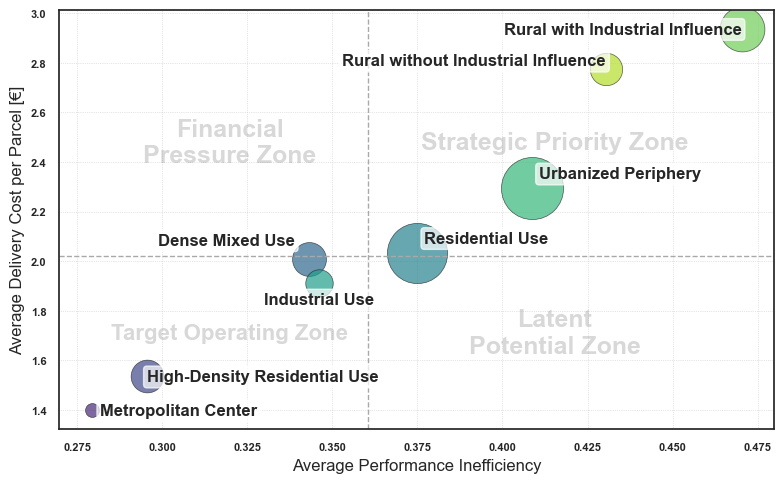

In [92]:
import matplotlib.pyplot as plt
import numpy as np

# 1) Define color mapping
category_color_dict = {
    "Metropolitan Center": "#482878",
    "High-Density Residential Use": "#3f4989",
    "Dense Mixed Use": "#31688e",
    "Residential Use": "#26828e",
    "Industrial Use": "#1f9e89",
    "Urbanized Periphery": "#35b779",
    "Rural with Industrial Influence": "#6fce58",
    "Rural without Industrial Influence": "#b5de2b"
}

# 2) Aggregate mean metrics and counts by area type
#    y wird jetzt als echte durchschnittliche Kosten pro Paket verwendet
agg = result.groupby('main_area_description').agg(
    ineff_perf=('inefficiency_perf', 'mean'),
    cost_per_parcel=('Cost per Parcel [€/parcel]', 'mean'),
    tour_count=('vehicle_id', 'count')
)

# 3) Scale bubble sizes by tour_count
min_size, max_size = 100, 2000
count_norm = (agg['tour_count'] - agg['tour_count'].min()) / (agg['tour_count'].max() - agg['tour_count'].min())
sizes = min_size + count_norm * (max_size - min_size)

# 4) Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

for area in agg.index:
    x = agg.at[area, 'ineff_perf']
    y = agg.at[area, 'cost_per_parcel']  # echte €-Kosten
    color = category_color_dict.get(area, 'gray')
    size = sizes.at[area]
    ax.scatter(x, y, s=size, color=color, alpha=0.7, edgecolor='k', linewidth=0.5)

# 5) Add quadrant lines (medians)
mp = agg['ineff_perf'].median()
mc = agg['cost_per_parcel'].median()
ax.axvline(mp, color='darkgray', linestyle='--', linewidth=1)
ax.axhline(mc, color='darkgray', linestyle='--', linewidth=1)

# 6) Individuelle Offsets pro Gebietstyp
offsets = {
    "Rural with Industrial Influence": dict(xytext=(0, 0), ha='right', va='center'),
    "Rural without Industrial Influence": dict(xytext=(0, 0), ha='right', va='bottom'),
    "Metropolitan Center": dict(xytext=(6,5), ha='left', va='top'),
    "High-Density Residential Use": dict(xytext=(0, 5), ha='left', va='top'),
    "Dense Mixed Use": dict(xytext=(-10, 8), ha='right', va='bottom'),   # nach links oben
    "Industrial Use": dict(xytext=(0, -7), ha='center', va='top'),      # nach unten
}
default = dict(xytext=(5, 5), ha='left', va='bottom')

for area in agg.index:
    x = agg.at[area, 'ineff_perf']
    y = agg.at[area, 'cost_per_parcel']
    params = offsets.get(area, default)
    ax.annotate(
        area,
        xy=(x, y),
        xytext=params['xytext'],
        textcoords='offset points',
        ha=params['ha'],
        va=params['va'],
        fontsize=12,
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7)
    )

# 7) Legend for bubble sizes (tour count)
# counts_legend = np.linspace(agg['tour_count'].min(), agg['tour_count'].max(), 3, dtype=int)
# handles = []
# for c in counts_legend:
#     s = min_size + (c - agg['tour_count'].min()) / (agg['tour_count'].max() - agg['tour_count'].min()) * (max_size - min_size)
#     handles.append(ax.scatter([], [], s=s, color='lightgray', edgecolor='k'))
#     handles[-1].set_label(f"{c} tours")
# ax.legend(handles=handles, title="Tour Count", labelspacing=1.2, loc='upper left', bbox_to_anchor=(1,1))

# 8) Styling

# Quadrant-Beschriftungen als Hintergrund
# oben rechts
ax.text(mp + (agg['ineff_perf'].max() - mp) / 2,
        mc + (agg['cost_per_parcel'].max() - mc) / 2,
        "Strategic Priority Zone",
        fontsize=18, color='gray', alpha=0.3,
        ha='center', va='center', weight='bold')

# oben links
ax.text(mp - (mp - agg['ineff_perf'].min()) / 2,
        mc + (agg['cost_per_parcel'].max() - mc) / 2,
        "Financial\nPressure Zone",
        fontsize=18, color='gray', alpha=0.3,
        ha='center', va='center', weight='bold')

# unten links
ax.text(mp - (mp - agg['ineff_perf'].min()) / 2,
        mc - (mc - agg['cost_per_parcel'].min()) / 2,
        "Target Operating Zone",
        fontsize=16, color='gray', alpha=0.3,
        ha='center', va='center', weight='bold')

# unten rechts
ax.text(mp + (agg['ineff_perf'].max() - mp) / 2,
        mc - (mc - agg['cost_per_parcel'].min()) / 2,
        "Latent\nPotential Zone",
        fontsize=18, color='gray', alpha=0.3,
        ha='center', va='center', weight='bold')

ax.set_xlabel('Average Performance Inefficiency')
ax.set_ylabel('Average Delivery Cost per Parcel [€]')
# ax.set_title('Bubble Chart: Inefficiency by Area Type\n(Bubble size ∝ Number of Tours)', pad=15)
ax.grid(True, linestyle=':', linewidth=0.5)
# fig.savefig("tour_efficiency.pdf", dpi=300, bbox_inches='tight', format='pdf')

plt.tight_layout()
plt.show()


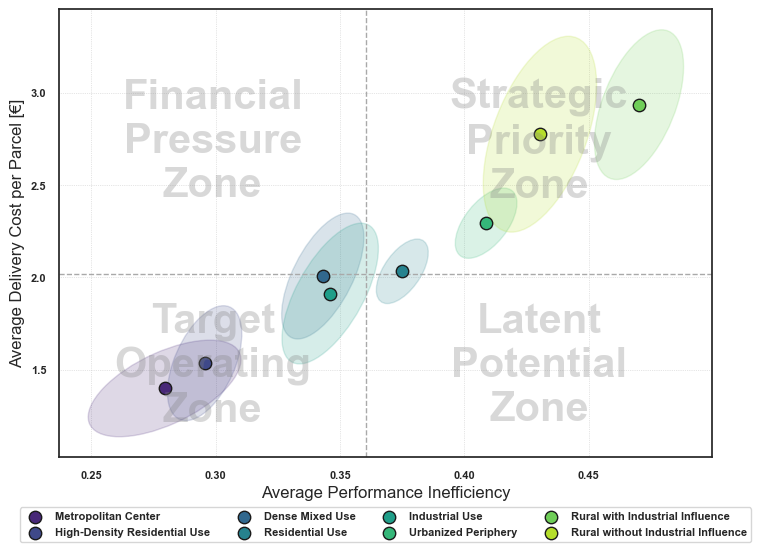

In [134]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Reproduzierbarkeit und Parameter
rng = np.random.default_rng(42)
n_boot = 100000
level = 0.95

# Farben
category_color_dict = {
    "Metropolitan Center": "#482878",
    "High-Density Residential Use": "#3f4989",
    "Dense Mixed Use": "#31688e",
    "Residential Use": "#26828e",
    "Industrial Use": "#1f9e89",
    "Urbanized Periphery": "#35b779",
    "Rural with Industrial Influence": "#6fce58",
    "Rural without Industrial Influence": "#b5de2b"
}

# Ellipsenfunktion auf Basis der Bootstraps der Mittelwerte
def ellipse_from_bootstrap(means, level=0.95):
    """
    means: Array der gebootstrappten Mittelwerte mit Form (B, 2)
    level: gewünschte Bedeckung, z. B. 0.95
    Rückgabe: center, width, height, angle
    """
    mu = means.mean(axis=0)
    cov = np.cov(means.T)
    # Eigenzerlegung der Kovarianz
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    # Mahalanobis Distanzen der Bootstraps
    diffs = means - mu
    inv_cov = np.linalg.inv(cov)
    md2 = np.einsum("ij,jk,ik->i", diffs, inv_cov, diffs)
    q = np.quantile(md2, level)  # Skalenfaktor^2
    a = np.sqrt(vals[0] * q)
    b = np.sqrt(vals[1] * q)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * a, 2 * b
    return mu, width, height, angle

# Aggregation wie gewünscht
agg = result.groupby('main_area_description').agg(
    ineff_perf=('inefficiency_perf', 'mean'),
    cost_per_parcel=('Cost per Parcel [€/parcel]', 'mean'),
    tour_count=('vehicle_id', 'count')
)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Legendeneinträge nur einmal
handled_labels = set()

for area, color in category_color_dict.items():
    if area not in agg.index:
        continue
    sub = result[result['main_area_description'] == area]
    if sub.empty or len(sub) < 3:
        # Für sehr kleine Stichproben keine Ellipse, nur Punkt
        mx = agg.at[area, 'ineff_perf']
        my = agg.at[area, 'cost_per_parcel']
        label = area if area not in handled_labels else None
        ax.scatter(mx, my, color=color, edgecolor='k', s=80, zorder=3, label=label)
        handled_labels.add(area)
        continue

    # Bootstrap der Mittelwerte
    vals = sub[['inefficiency_perf', 'Cost per Parcel [€/parcel]']].to_numpy()
    n = len(vals)
    means = np.empty((n_boot, 2))
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        means[b] = vals[idx].mean(axis=0)

    # Ellipse aus Bootstraps
    center, width, height, angle = ellipse_from_bootstrap(means, level=level)

    # Gefüllte Ellipse mit viel Alpha
    ell = Ellipse(
        xy=center, width=width, height=height, angle=angle,
        facecolor=color, edgecolor=color, alpha=0.18, linewidth=1.0, zorder=2
    )
    ax.add_patch(ell)

    # Punkt exakt auf den aggregierten Mittelwert
    mx = agg.at[area, 'ineff_perf']
    my = agg.at[area, 'cost_per_parcel']
    label = area if area not in handled_labels else None
    ax.scatter(mx, my, color=color, edgecolor='k', s=80, zorder=3, label=label, alpha=1)
    handled_labels.add(area)

# Medianlinien aus den aggregierten Werten
mp = agg['ineff_perf'].median()
mc = agg['cost_per_parcel'].median()
ax.axvline(mp, color='darkgray', linestyle='--', linewidth=1)
ax.axhline(mc, color='darkgray', linestyle='--', linewidth=1)

# aktuelle Achsengrenzen
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# horizontale und vertikale Mittelpunkte
x_left  = (x_min + mp) / 2
x_right = (x_max + mp) / 2
y_bottom = (y_min + mc) / 2
y_top    = (y_max + mc) / 2

# oben rechts
ax.text(x_right, y_top,
        "Strategic\nPriority\nZone",
        fontsize=30, color='gray', alpha=0.3,
        ha='center', va='center', weight='bold', zorder=4)

# oben links
ax.text(x_left, y_top,
        "Financial\nPressure\nZone",
        fontsize=30, color='gray', alpha=0.3,
        ha='center', va='center', weight='bold', zorder=4)

# unten links
ax.text(x_left, y_bottom,
        "Target\nOperating\nZone",
        fontsize=30, color='gray', alpha=0.3,
        ha='center', va='center', weight='bold', zorder=4)

# unten rechts
ax.text(x_right, y_bottom,
        "Latent\nPotential\nZone",
        fontsize=30, color='gray', alpha=0.3,
        ha='center', va='center', weight='bold', zorder=4)


ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),  # weiter nach unten verschieben
    ncol=4,
    frameon=True,
    fontsize=8,

)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # mehr Platz unten für die Legende

ax.set_xlabel('Average Performance Inefficiency')
ax.set_ylabel('Average Delivery Cost per Parcel [€]')
ax.grid(True, linestyle=':', linewidth=0.5)
# ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Area Type')
# plt.tight_layout()
plt.savefig("means_ellipse_bootstrap.pdf", dpi=300, bbox_inches="tight")
plt.show()


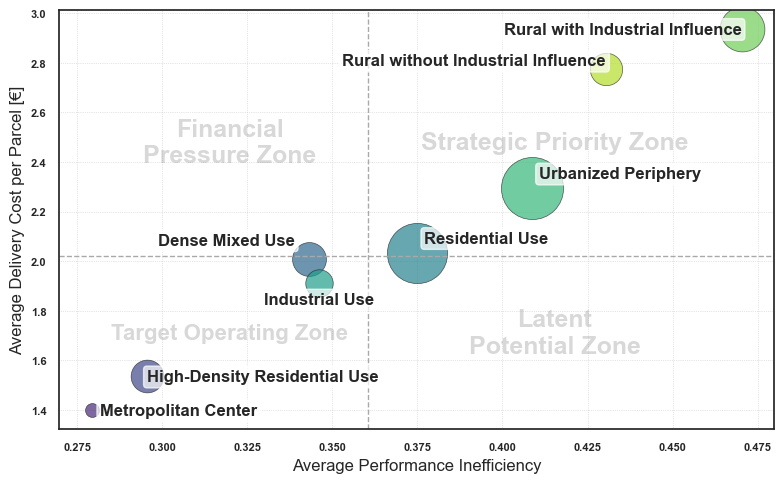

In [99]:
import matplotlib.pyplot as plt
import numpy as np

# Farben
category_color_dict = {
    "Metropolitan Center": "#482878",
    "High-Density Residential Use": "#3f4989",
    "Dense Mixed Use": "#31688e",
    "Residential Use": "#26828e",
    "Industrial Use": "#1f9e89",
    "Urbanized Periphery": "#35b779",
    "Rural with Industrial Influence": "#6fce58",
    "Rural without Industrial Influence": "#b5de2b"
}

# Aggregation
agg = result.groupby('main_area_description').agg(
    ineff_perf=('inefficiency_perf', 'mean'),
    cost_per_parcel=('Cost per Parcel [€/parcel]', 'mean'),
    tour_count=('vehicle_id', 'count')
)

# Bubblegrößen (optional)
min_size, max_size = 100, 2000
count_norm = (agg['tour_count'] - agg['tour_count'].min()) / (agg['tour_count'].max() - agg['tour_count'].min())
sizes = min_size + count_norm * (max_size - min_size)

fig, ax = plt.subplots(figsize=(8, 5))

# Plot Punkte
for area in agg.index:
    x = agg.at[area, 'ineff_perf']
    y = agg.at[area, 'cost_per_parcel']
    color = category_color_dict.get(area, 'gray')
    size = sizes.at[area]
    ax.scatter(x, y, s=size, color=color, alpha=0.7, edgecolor='k', linewidth=0.5)

# Medianlinien
mp = agg['ineff_perf'].median()
mc = agg['cost_per_parcel'].median()
ax.axvline(mp, color='darkgray', linestyle='--', linewidth=1)
ax.axhline(mc, color='darkgray', linestyle='--', linewidth=1)

# Individuelle Offsets pro Gebietstyp
offsets = {
    "Rural with Industrial Influence": dict(xytext=(0, 0), ha='right', va='center'),
    "Rural without Industrial Influence": dict(xytext=(0, 0), ha='right', va='bottom'),
    "Metropolitan Center": dict(xytext=(6,5), ha='left', va='top'),
    "High-Density Residential Use": dict(xytext=(0, 5), ha='left', va='top'),
    "Dense Mixed Use": dict(xytext=(-10, 8), ha='right', va='bottom'),
    "Industrial Use": dict(xytext=(0, -7), ha='center', va='top'),
}
default = dict(xytext=(5, 5), ha='left', va='bottom')

# Labels direkt an die Punkte
for area in agg.index:
    x = agg.at[area, 'ineff_perf']
    y = agg.at[area, 'cost_per_parcel']
    params = offsets.get(area, default)
    ax.annotate(
        area,
        xy=(x, y),
        xytext=params['xytext'],
        textcoords='offset points',
        ha=params['ha'],
        va=params['va'],
        fontsize=12,
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7)
    )

# Quadrant-Beschriftungen
ax.text(mp + (agg['ineff_perf'].max() - mp) / 2,
        mc + (agg['cost_per_parcel'].max() - mc) / 2,
        "Strategic Priority Zone",
        fontsize=18, color='gray', alpha=0.3,
        ha='center', va='center', weight='bold')

ax.text(mp - (mp - agg['ineff_perf'].min()) / 2,
        mc + (agg['cost_per_parcel'].max() - mc) / 2,
        "Financial\nPressure Zone",
        fontsize=18, color='gray', alpha=0.3,
        ha='center', va='center', weight='bold')

ax.text(mp - (mp - agg['ineff_perf'].min()) / 2,
        mc - (mc - agg['cost_per_parcel'].min()) / 2,
        "Target Operating Zone",
        fontsize=16, color='gray', alpha=0.3,
        ha='center', va='center', weight='bold')

ax.text(mp + (agg['ineff_perf'].max() - mp) / 2,
        mc - (mc - agg['cost_per_parcel'].min()) / 2,
        "Latent\nPotential Zone",
        fontsize=18, color='gray', alpha=0.3,
        ha='center', va='center', weight='bold')

# Achsenbeschriftung
ax.set_xlabel('Average Performance Inefficiency')
ax.set_ylabel('Average Delivery Cost per Parcel [€]')
ax.grid(True, linestyle=':', linewidth=0.5)

plt.tight_layout()
plt.show()


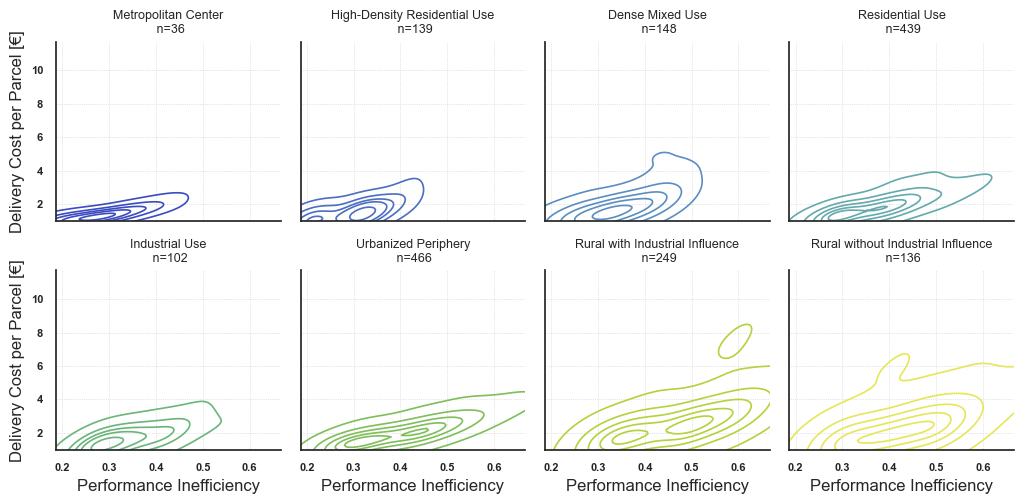

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

order = [
    "Metropolitan Center",
    "High-Density Residential Use",
    "Dense Mixed Use",
    "Residential Use",
    "Industrial Use",
    "Urbanized Periphery",
    "Rural with Industrial Influence",
    "Rural without Industrial Influence"      
]

palette = {
    "Metropolitan Center": "#3b4cc0",
    "High-Density Residential Use": "#4b6ec2",
    "Dense Mixed Use": "#5a8ec1",
    "Residential Use": "#64a9ac",
    "Industrial Use": "#69b57a",
    "Urbanized Periphery": "#7fbe5a",
    "Rural with Industrial Influence": "#b3d23b",
    "Rural without Industrial Influence": "#e6e658",
}

x = "inefficiency_perf"
y = "Cost per Parcel [€/parcel]"

# globale Achsengrenzen einmal festlegen
xlim = (result[x].quantile(0.01), result[x].quantile(0.99))
ylim = (result[y].quantile(0.01), result[y].quantile(0.99))

g = sns.FacetGrid(
    data=result[result["main_area_description"].isin(order)],
    col="main_area_description",
    col_wrap=4,
    hue="main_area_description",
    col_order=order,   # <- Reihenfolge fix
    palette=palette,
    sharex=True,
    sharey=True,
    height=2.6
)

g.map_dataframe(
    sns.kdeplot,
    x=x, y=y,
    fill=False,
    levels=[0.1, 0.3, 0.5, 0.7, 0.9],
    thresh=0.05,
    linewidths=1.2
)

for ax, cat in zip(g.axes.flatten(), order):
    sub = result[result["main_area_description"] == cat]
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.grid(True, linestyle=":", linewidth=0.5)
    ax.set_title(f"{cat}\n n={len(sub)}", fontsize=9)
    # optionale globale Medianlinien
    # ax.axvline(result[x].median(), color="0.6", linestyle="--", linewidth=0.8)
    # ax.axhline(result[y].median(), color="0.6", linestyle="--", linewidth=0.8)

g.set_xlabels("Performance Inefficiency")
g.set_ylabels("Delivery Cost per Parcel [€]")
plt.tight_layout()
# plt.savefig("kde_small_multiples.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [68]:
# ----------------------
# 9) Statistische Auswertung
# ----------------------

# Globale Mittelwerte
avg_cost = agg['cost_per_parcel'].mean()
avg_ineff = agg['ineff_perf'].mean()

print("=== Durchschnittswerte (über alle Area Types) ===")
print(f"Average inefficiency: {avg_ineff:.3f}")
print(f"Average cost per parcel: {avg_cost:.2f} €")
print()

# Bereichsdefinitionen für Quadranten
zones = {
    "Strategic Priority Zone (oben rechts)": {
        "inefficiency": f"> {mp:.3f}",
        "cost": f"> {mc:.2f}"
    },
    "Financial Pressure Zone (oben links)": {
        "inefficiency": f"≤ {mp:.3f}",
        "cost": f"> {mc:.2f}"
    },
    "Target Operating Zone (unten links)": {
        "inefficiency": f"≤ {mp:.3f}",
        "cost": f"≤ {mc:.2f}"
    },
    "Latent Potential Zone (unten rechts)": {
        "inefficiency": f"> {mp:.3f}",
        "cost": f"≤ {mc:.2f}"
    }
}

print("=== Zonenbereiche (Definition) ===")
for zone, cond in zones.items():
    print(f"{zone}: Inefficiency {cond['inefficiency']}, Cost {cond['cost']}")

# Optional: Zählung wie viele Area Types in welchem Quadranten liegen
def classify(x, y, mp, mc):
    if x > mp and y > mc:
        return "Strategic Priority Zone"
    elif x <= mp and y > mc:
        return "Financial Pressure Zone"
    elif x <= mp and y <= mc:
        return "Target Operating Zone"
    else:
        return "Latent Potential Zone"

# Klassifikation je Area Type
def classify(x, y, mp, mc):
    if x > mp and y > mc:
        return "Strategic Priority Zone"
    elif x <= mp and y > mc:
        return "Financial Pressure Zone"
    elif x <= mp and y <= mc:
        return "Target Operating Zone"
    else:
        return "Latent Potential Zone"

agg['zone'] = agg.apply(
    lambda r: classify(r['ineff_perf'], r['cost_per_parcel'], mp, mc), axis=1
)

print()
print("=== Area Types nach Zonen ===")
for zone, subset in agg.groupby('zone'):
    print(f"\n{zone} ({len(subset)} Area Types):")
    for area in subset.index:
        inef = subset.at[area, 'ineff_perf']
        cost = subset.at[area, 'cost_per_parcel']
        print(f"  - {area}: ineff={inef:.3f}, cost={cost:.2f} €")


=== Durchschnittswerte (über alle Area Types) ===
Average inefficiency: 0.369
Average cost per parcel: 2.11 €

=== Zonenbereiche (Definition) ===
Strategic Priority Zone (oben rechts): Inefficiency > 0.361, Cost > 2.02
Financial Pressure Zone (oben links): Inefficiency ≤ 0.361, Cost > 2.02
Target Operating Zone (unten links): Inefficiency ≤ 0.361, Cost ≤ 2.02
Latent Potential Zone (unten rechts): Inefficiency > 0.361, Cost ≤ 2.02

=== Area Types nach Zonen ===

Strategic Priority Zone (4 Area Types):
  - Residential Use: ineff=0.375, cost=2.03 €
  - Rural with Industrial Influence: ineff=0.470, cost=2.93 €
  - Rural without Industrial Influence: ineff=0.430, cost=2.78 €
  - Urbanized Periphery: ineff=0.409, cost=2.29 €

Target Operating Zone (4 Area Types):
  - Dense Mixed Use: ineff=0.343, cost=2.01 €
  - High-Density Residential Use: ineff=0.296, cost=1.54 €
  - Industrial Use: ineff=0.346, cost=1.91 €
  - Metropolitan Center: ineff=0.279, cost=1.40 €


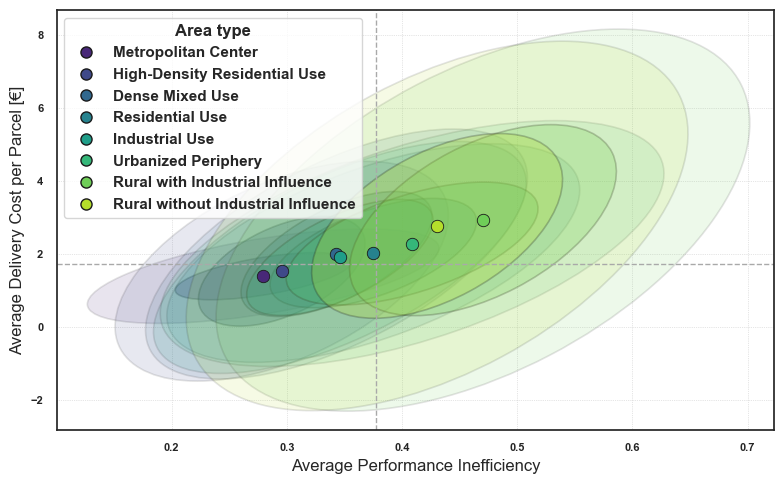

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Annahmen: DataFrame 'result' enthält
# 'main_area_description', 'inefficiency_perf', 'Cost per Parcel [€/parcel]'

category_color_dict = {
    "Metropolitan Center": "#482878",
    "High-Density Residential Use": "#3f4989",
    "Dense Mixed Use": "#31688e",
    "Residential Use": "#26828e",
    "Industrial Use": "#1f9e89",
    "Urbanized Periphery": "#35b779",
    "Rural with Industrial Influence": "#6fce58",
    "Rural without Industrial Influence": "#b5de2b"
}

def covariance_ellipse_params(x, y):
    """Gibt Mittelpunkt, Breiten, Höhen und Winkel der Kovarianzellipse zurück."""
    x = np.asarray(x); y = np.asarray(y)
    mx, my = x.mean(), y.mean()
    cov = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    # Halbachsen für 1 sigma
    a1, b1 = np.sqrt(vals[0]), np.sqrt(vals[1])
    return (mx, my), a1, b1, angle

def add_sigma_ellipses(ax, df, color, label=None, lw=1.2):
    """Zeichnet 1σ und 2σ Ellipsen auf die Achse ax."""
    if len(df) < 3:
        return
    (mx, my), a1, b1, angle = covariance_ellipse_params(
        df['inefficiency_perf'], df['Cost per Parcel [€/parcel]']
    )
    # 1 sigma
    e1 = Ellipse(xy=(mx, my), width=2*a1, height=2*b1, angle=angle,
                 facecolor=color, edgecolor='k', linewidth=lw, alpha=0.25,
                 label=label if label else None)
    # 2 sigma
    e2 = Ellipse(xy=(mx, my), width=4*a1, height=4*b1, angle=angle,
                 facecolor=color, edgecolor='k', linewidth=lw, alpha=0.12)
    ax.add_patch(e2)
    ax.add_patch(e1)
    # Mean Punkt
    ax.scatter(mx, my, s=80, color=color, edgecolor='k', linewidth=0.6, zorder=3)

fig, ax = plt.subplots(figsize=(8, 5))

# Ellipsen pro Gebietstyp
for i, (area, color) in enumerate(category_color_dict.items()):
    df = result[result['main_area_description'] == area]
    if df.empty:
        continue
    add_sigma_ellipses(ax, df, color, label=area if i < 8 else None)

# Optional: Medianlinien global
mp = result['inefficiency_perf'].median()
mc = result['Cost per Parcel [€/parcel]'].median()
ax.axvline(mp, color='darkgray', linestyle='--', linewidth=1)
ax.axhline(mc, color='darkgray', linestyle='--', linewidth=1)

ax.set_xlabel('Average Performance Inefficiency')
ax.set_ylabel('Average Delivery Cost per Parcel [€]')
ax.grid(True, linestyle=':', linewidth=0.5)

# Schlichte Legende mit Proxy über Punkte
handles = [plt.Line2D([0], [0], marker='o', linestyle='', markersize=8,
                      markerfacecolor=c, markeredgecolor='k', label=n)
           for n, c in category_color_dict.items()]
ax.legend(handles=handles, title='Area type', loc='upper left', frameon=True)

plt.tight_layout()
# fig.savefig('tour_ellipses_1sigma_2sigma.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [73]:
result

,vehicle_id,Start time,End time,Tour Duration (hrs),Service Duration,Driving Time (hrs),Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,Cost per B2B Parcel [€/parcel],Cost per B2C Parcel [€/parcel],Cost per Kilogram [€/kg],inefficiency_cost,inefficiency_perf,inefficiency_total,carrier_name,plz_gebiet,split,carrier
0,freight_gls_30900_veh_cep_size_m_7_3,24971,69117,0.003406,15206,0.002233,1970-01-01 06:56:11,1970-01-01 19:11:57,1970-01-01 12:15:46,1970-01-01 04:13:26,...,3.020783,3.020783,0.675279,0.107762,0.566158,0.336960,gls,30900,<NA>,gls_30900
1,freight_gls_30900_veh_cep_size_m_7_2,24971,66547,0.003208,14078,0.002122,1970-01-01 06:56:11,1970-01-01 18:29:07,1970-01-01 11:32:56,1970-01-01 03:54:38,...,3.083288,3.083288,0.746527,0.110875,0.588037,0.349456,gls,30900,<NA>,gls_30900
2,freight_gls_30900_veh_cep_size_l_7_1,25065,66363,0.003187,14726,0.002050,1970-01-01 06:57:45,1970-01-01 18:26:03,1970-01-01 11:28:18,1970-01-01 04:05:26,...,3.062653,3.062653,0.718539,0.109848,0.604266,0.357057,gls,30900,<NA>,gls_30900
3,freight_dpd_30890_veh_cep_size_m_7_3,25228,54480,0.002257,11580,0.001364,1970-01-01 07:00:28,1970-01-01 15:08:00,1970-01-01 08:07:32,1970-01-01 03:13:00,...,2.669586,2.669586,0.567907,0.090268,0.570060,0.330164,dpd,30890,<NA>,dpd_30890
4,freight_dpd_30890_veh_cep_size_m_7_1,25228,53024,0.002145,8299,0.001504,1970-01-01 07:00:28,1970-01-01 14:43:44,1970-01-01 07:43:16,1970-01-01 02:18:19,...,3.509993,3.509993,0.704396,0.132130,0.621008,0.376569,dpd,30890,<NA>,dpd_30890
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1733,freight_dhl_31535_0_veh_cep_size_m_14_7,54492,60510,0.000464,2685,0.000257,1970-01-01 15:08:12,1970-01-01 16:48:30,1970-01-01 01:40:18,1970-01-01 00:44:45,...,8.106410,8.106410,1.496652,0.361087,0.441837,0.401462,dhl,31535,0,dhl_31535_0
1734,freight_amazon_30159_veh_cep_size_m_15_4,54918,73401,0.001426,12271,0.000479,1970-01-01 15:15:18,1970-01-01 20:23:21,1970-01-01 05:08:03,1970-01-01 03:24:31,...,NaN,1.889456,0.566146,0.051408,0.353369,0.202389,amazon,30159,<NA>,amazon_30159
1735,freight_amazon_30171_veh_cep_size_m_16_4,57766,74940,0.001325,10520,0.000513,1970-01-01 16:02:46,1970-01-01 20:49:00,1970-01-01 04:46:14,1970-01-01 02:55:20,...,2.231840,2.231840,0.483874,0.068463,0.392044,0.230254,amazon,30171,<NA>,amazon_30171
1736,freight_amazon_30826_veh_cep_size_m_17_6,60518,67219,0.000517,3820,0.000222,1970-01-01 16:48:38,1970-01-01 18:40:19,1970-01-01 01:51:41,1970-01-01 01:03:40,...,NaN,5.840609,2.325442,0.248223,0.419006,0.333615,amazon,30826,<NA>,amazon_30826


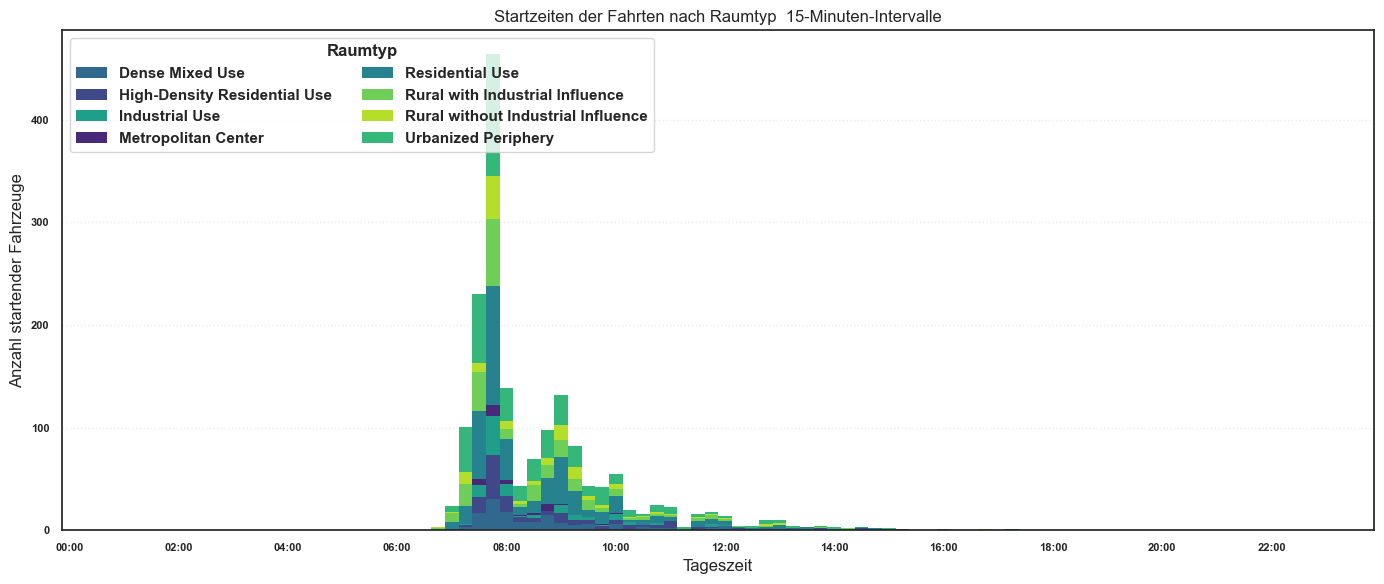

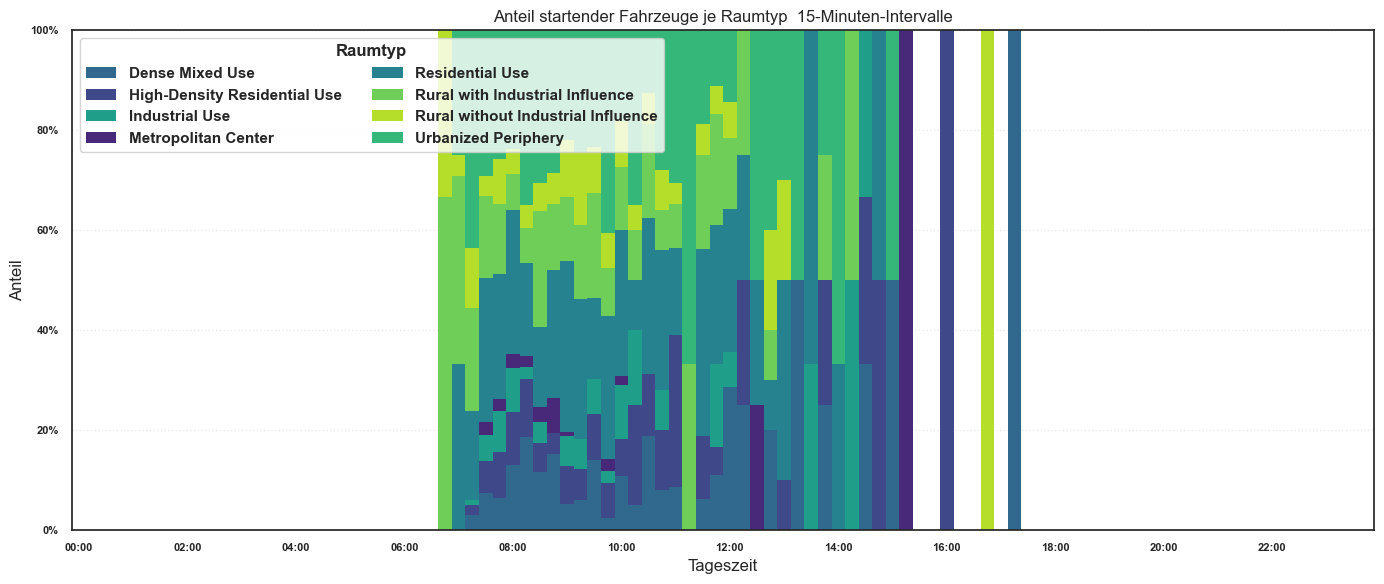

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# counts wie zuvor berechnet:
# Index = time_slots (Strings 'HH:MM' für alle 96 Viertelstunden)
# Spalten = Raumtypen
# Beispiel: counts = df.groupby(["slot","Raumtyp"]).size().unstack(fill_value=0).reindex(time_slots).fillna(0)

# Farben pro Raumtyp
name_to_color = {
    "Metropolitan Center": "#482878",
    "High-Density Residential Use": "#3f4989",
    "Dense Mixed Use": "#31688e",
    "Residential Use": "#26828e",
    "Industrial Use": "#1f9e89",
    "Urbanized Periphery": "#35b779",
    "Rural with Industrial Influence": "#6fce58",
    "Rural without Industrial Influence": "#b5de2b",
    "Unknown": "#999999"
}
bar_colors = [name_to_color.get(c, "#999999") for c in counts.columns]

# X als Integer-Positionen
x = np.arange(len(counts))
tick_step = 8  # alle 2 Stunden markieren, da 4 Slots pro Stunde

# 1) Gestapelte Balken, absolute Starts
fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(len(counts), dtype=float)

for col, color in zip(counts.columns, bar_colors):
    y = counts[col].to_numpy(dtype=float)
    ax.bar(x, y, bottom=bottom, width=1.0, color=color, edgecolor="none", label=col)
    bottom += y

ax.set_xlim(-0.5, len(x) - 0.5)
ax.set_xticks(np.arange(0, len(x), tick_step))
ax.set_xticklabels(counts.index[::tick_step], rotation=0)
ax.set_title("Startzeiten der Fahrten nach Raumtyp  15-Minuten-Intervalle")
ax.set_xlabel("Tageszeit")
ax.set_ylabel("Anzahl startender Fahrzeuge")
ax.legend(title="Raumtyp", ncol=2, loc="upper left")
ax.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

# 2) 100-Prozent-gestapelte Balken, Anteile je Slot
shares = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)

fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(len(shares), dtype=float)

for col, color in zip(shares.columns, bar_colors):
    y = shares[col].to_numpy(dtype=float)
    ax.bar(x, y, bottom=bottom, width=1.0, color=color, edgecolor="none", label=col)
    bottom += y

ax.set_xlim(-0.5, len(x) - 0.5)
ax.set_xticks(np.arange(0, len(x), tick_step))
ax.set_xticklabels(shares.index[::tick_step], rotation=0)
ax.set_title("Anteil startender Fahrzeuge je Raumtyp  15-Minuten-Intervalle")
ax.set_xlabel("Tageszeit")
ax.set_ylabel("Anteil")
import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(title="Raumtyp", ncol=2, loc="upper left")
ax.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()
